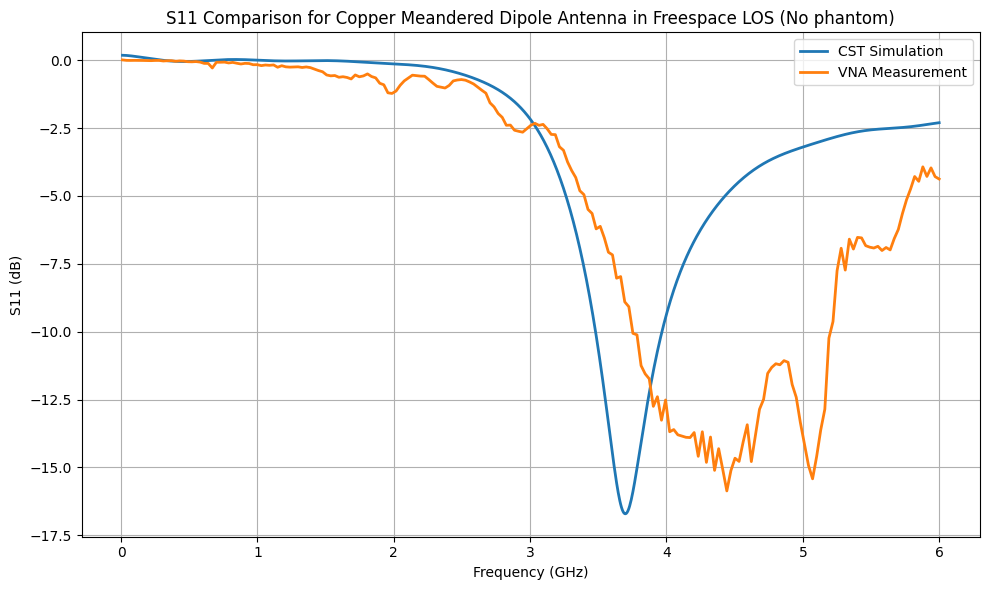

In [ ]:

!pip install scikit-rf

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
txt_file = "CST_Copper_PhantomRemoved_S11.txt"
s2p_file = "CopperFreespaceLOS_7thMay10MHzto6Ghz.s2p"

# -----------------------------
# Load CST TXT file
# Assumes:
# Column 1 = Frequency
# Column 2 = S11 magnitude (dB)
# -----------------------------
txt_data = np.loadtxt(txt_file)

freq_txt = txt_data[:, 0]
s11_txt = txt_data[:, 1]

# Convert frequency to GHz if needed
# Uncomment if frequencies are in Hz
# freq_txt = freq_txt / 1e9

# -----------------------------
# Load Touchstone S2P file
# -----------------------------
freq_s2p = []
s11_s2p_db = []

with open(s2p_file, 'r') as f:
    for line in f:
        line = line.strip()

        # Skip comments and option lines
        if not line or line.startswith('!'):
            continue

        # Parse option line
        if line.startswith('#'):
            option_line = line.upper()

            # Determine frequency unit
            if 'GHZ' in option_line:
                freq_scale = 1
            elif 'MHZ' in option_line:
                freq_scale = 1e-3
            elif 'KHZ' in option_line:
                freq_scale = 1e-6
            elif 'HZ' in option_line:
                freq_scale = 1e-9
            else:
                freq_scale = 1

            # Determine data format
            if 'DB' in option_line:
                data_format = 'DB'
            elif 'MA' in option_line:
                data_format = 'MA'
            elif 'RI' in option_line:
                data_format = 'RI'

            continue

        values = line.split()

        # Standard S2P has:
        # freq S11 S21 S12 S22
        # each S-param has 2 values depending on format
        values = [float(v) for v in values]

        freq = values[0] * freq_scale

        if data_format == 'DB':
            s11_db = values[1]

        elif data_format == 'MA':
            mag = values[1]
            s11_db = 20 * np.log10(mag)

        elif data_format == 'RI':
            real = values[1]
            imag = values[2]
            mag = np.sqrt(real**2 + imag**2)
            s11_db = 20 * np.log10(mag)

        freq_s2p.append(freq)
        s11_s2p_db.append(s11_db)

freq_s2p = np.array(freq_s2p)
s11_s2p_db = np.array(s11_s2p_db)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq_txt, s11_txt,
         label='CST Simulation',
         linewidth=2)

plt.plot(freq_s2p, s11_s2p_db,
         label='VNA Measurement',
         linewidth=2)

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('S11 Comparison for Copper Meandered Dipole Antenna in Freespace LOS (No phantom)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Sim_and_Measurements_S11_plot.png", dpi=300, bbox_inches='tight')


plt.show()


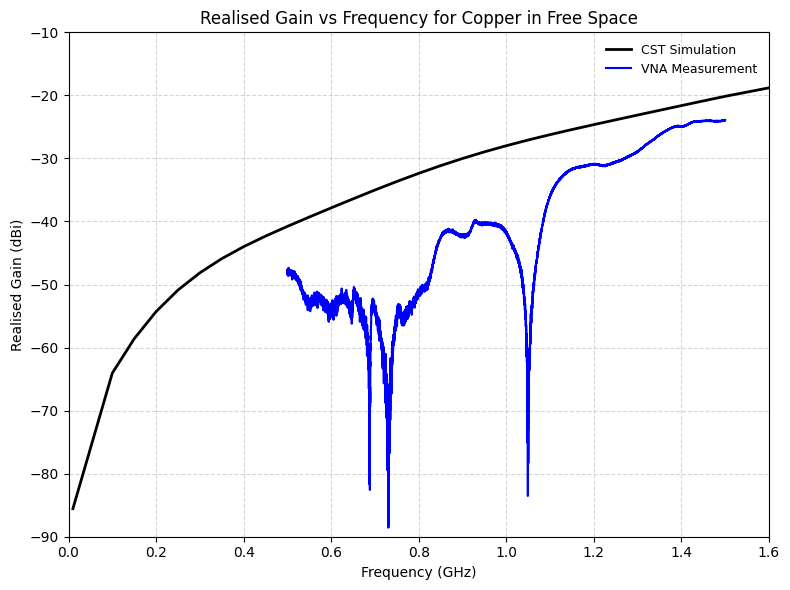

In [ ]:
!pip install scikit-rf
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

simdata = np.loadtxt("CST_Copper_PhantomRemoved_Farfield_realisedGain.txt")
x3 = simdata[:, 0]
y3 = simdata[:, 1]


# -----------------------------
# USER INPUTS
# -----------------------------

d = 0.5                      # distance in meters
Gr = 6                       # receiver gain in dB
Pt = 0                       # transmitted power in dB
c = 3e8                      # speed of light (m/s)

# -----------------------------
# EXTRACT DATA
# -----------------------------

ntwk = rf.Network('Copper_Dipole_Ave10,F_500M_1500MHz.s2p')
freq = ntwk.f                      # frequency in Hz
s21_db = ntwk.s_db[:, 1, 0]        # S21 in dB

# -----------------------------
# FILTER 0.6–1.2 GHz
# -----------------------------
mask = (freq >= 0e1) & (freq <= 1500e6)
freq = freq[mask]
s21_db = s21_db[mask]

# -----------------------------
# RECEIVED POWER
# -----------------------------
Pr = s21_db  # since Pt = 0 dB

# -----------------------------
# FREE SPACE PATH LOSS (FSPL)
# -----------------------------
fspl = 20*np.log10(d) + 20*np.log10(freq) + 20*np.log10(4*np.pi / c)

# -----------------------------
# CALCULATE Gt
# -----------------------------
Gt = Pr - Pt + fspl - Gr
# since Pt = 0 → Gt = Pr + fspl - Gr



# -----------------------------
# PLOT RESULTS
# -----------------------------
plt.figure(figsize=(8,6))

# Copper curve (highlighted)
plt.plot(
    x3, y3,
    color="black",
    linewidth=2,
    label="CST Simulation"
)

plt.xlim(0,1.6) #Limits are 0.1 - 1.5/6
plt.ylim(-90, -10)

plt.plot(freq / 1e9, Gt, label='VNA Measurement', color='blue')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Realised Gain (dBi)')
plt.title('Realised Gain vs Frequency for Copper in Free Space')
plt.grid(True)
plt.legend()

# Grid (subtle)
plt.grid(True, linestyle='--', alpha=0.5)

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Legend (clean placement)
plt.legend(fontsize=9, loc='best', frameon=False)

plt.tight_layout()

# Save high-quality outputs
plt.savefig("Sim_and_Measurements_Gain_plot.png", dpi=300, bbox_inches='tight')

plt.show()

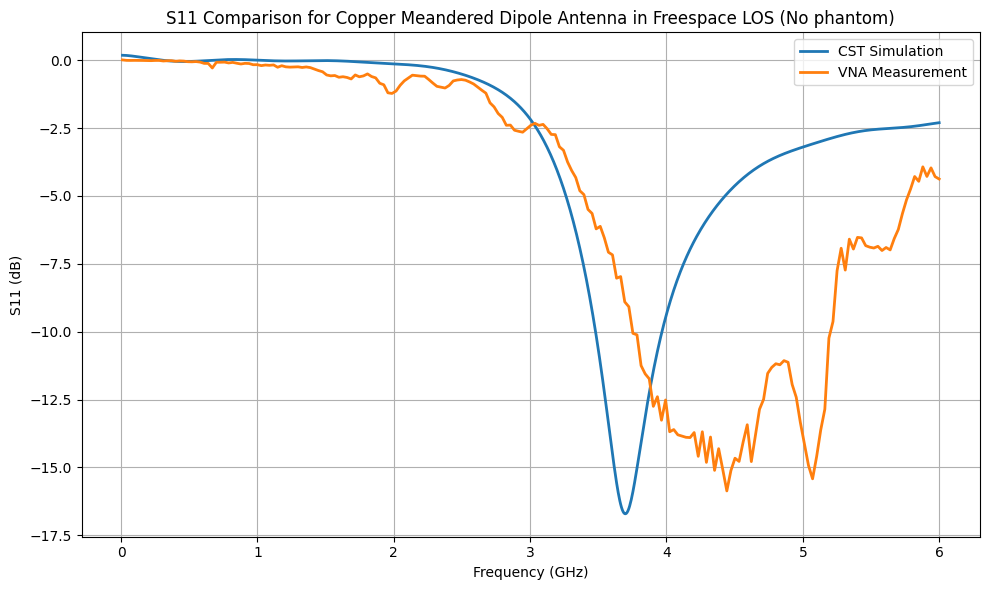

In [ ]:
!pip install scikit-rf


import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
txt_file = "CST_Copper_PhantomRemoved_S11.txt"
s2p_file = "CopperFreespaceLOS_7thMay10MHzto6Ghz.s2p"

# -----------------------------
# Load CST TXT file
# Assumes:
# Column 1 = Frequency
# Column 2 = S11 magnitude (dB)
# -----------------------------
txt_data = np.loadtxt(txt_file)

freq_txt = txt_data[:, 0]
s11_txt = txt_data[:, 1]

# Convert frequency to GHz if needed
# Uncomment if frequencies are in Hz
# freq_txt = freq_txt / 1e9

# -----------------------------
# Load Touchstone S2P file
# -----------------------------
freq_s2p = []
s11_s2p_db = []

with open(s2p_file, 'r') as f:
    for line in f:
        line = line.strip()

        # Skip comments and option lines
        if not line or line.startswith('!'):
            continue

        # Parse option line
        if line.startswith('#'):
            option_line = line.upper()

            # Determine frequency unit
            if 'GHZ' in option_line:
                freq_scale = 1
            elif 'MHZ' in option_line:
                freq_scale = 1e-3
            elif 'KHZ' in option_line:
                freq_scale = 1e-6
            elif 'HZ' in option_line:
                freq_scale = 1e-9
            else:
                freq_scale = 1

            # Determine data format
            if 'DB' in option_line:
                data_format = 'DB'
            elif 'MA' in option_line:
                data_format = 'MA'
            elif 'RI' in option_line:
                data_format = 'RI'

            continue

        values = line.split()

        # Standard S2P has:
        # freq S11 S21 S12 S22
        # each S-param has 2 values depending on format
        values = [float(v) for v in values]

        freq = values[0] * freq_scale

        if data_format == 'DB':
            s11_db = values[1]

        elif data_format == 'MA':
            mag = values[1]
            s11_db = 20 * np.log10(mag)

        elif data_format == 'RI':
            real = values[1]
            imag = values[2]
            mag = np.sqrt(real**2 + imag**2)
            s11_db = 20 * np.log10(mag)

        freq_s2p.append(freq)
        s11_s2p_db.append(s11_db)

freq_s2p = np.array(freq_s2p)
s11_s2p_db = np.array(s11_s2p_db)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq_txt, s11_txt,
         label='CST Simulation',
         linewidth=2)

plt.plot(freq_s2p, s11_s2p_db,
         label='VNA Measurement',
         linewidth=2)

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('S11 Comparison for Copper Meandered Dipole Antenna in Freespace LOS (No phantom)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Sim_and_Measurements_S11_plot.png", dpi=300, bbox_inches='tight')


plt.show()

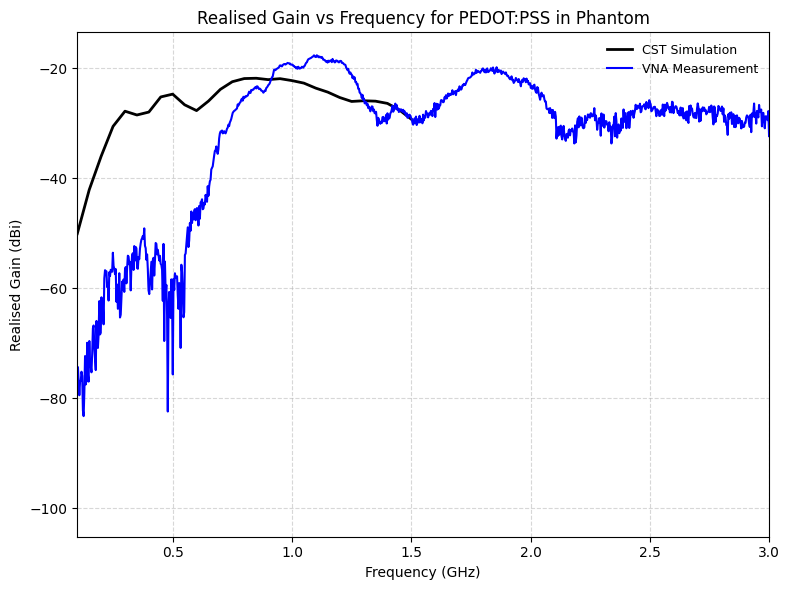

In [ ]:
!pip install scikit-rf

import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]


ntwk = rf.Network('pedot_Dipole_F_10M_3000MHz_block sqashed 1.s2p')

# -----------------------------
# USER INPUTS
# -----------------------------

d = 1.5                      # distance in meters
Gr = 6                       # receiver gain in dB
Pt = 0                       # transmitted power in dB
c = 3e8                      # speed of light (m/s)

# -----------------------------
# EXTRACT DATA
# -----------------------------
freq = ntwk.f                      # frequency in Hz
s21_db = ntwk.s_db[:, 1, 0]        # S21 in dB

# -----------------------------
# FILTER 0.6–1.2 GHz
# -----------------------------
mask = (freq >= 00e1) & (freq <= 3000e6)
freq = freq[mask]
s21_db = s21_db[mask]

# -----------------------------
# RECEIVED POWER
# -----------------------------
Pr = s21_db  # since Pt = 0 dB

# -----------------------------
# FREE SPACE PATH LOSS (FSPL)
# -----------------------------
fspl = 20*np.log10(d) + 20*np.log10(freq) + 20*np.log10(4*np.pi / c)

# -----------------------------
# CALCULATE Gt
# -----------------------------
Gt = Pr - Pt + fspl - Gr
# since Pt = 0 → Gt = Pr + fspl - Gr



# -----------------------------
# PLOT RESULTS
# -----------------------------
plt.figure(figsize=(8,6))

# Pedot curve (highlighted)
plt.plot(
    x3, y3,
    color="black",
    linewidth=2,
    label="CST Simulation"
)

plt.xlim(0.1, 3) #Limits are 0.1 - 1.5/6
#plt.ylim(-40, -18)

plt.plot(freq / 1e9, Gt, label='VNA Measurement', color='blue')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Realised Gain (dBi)')
plt.title('Realised Gain vs Frequency for PEDOT:PSS in Phantom')
plt.grid(True)
plt.legend()

# Grid (subtle)
plt.grid(True, linestyle='--', alpha=0.5)

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Legend (clean placement)
plt.legend(fontsize=9, loc='best', frameon=False)

plt.tight_layout()

# Save high-quality outputs
plt.savefig("Sim_and_Measurements_Gain_plot.png", dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_22814/1716458157.py:66: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 6))


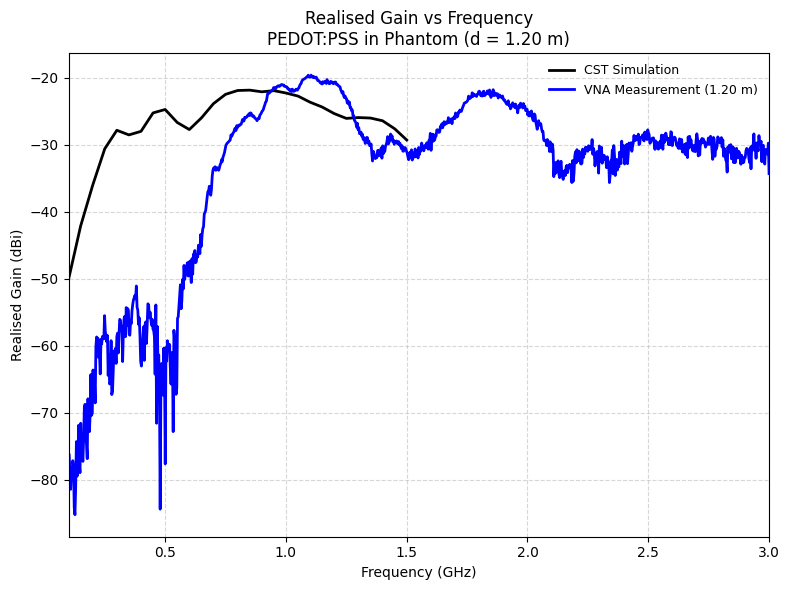

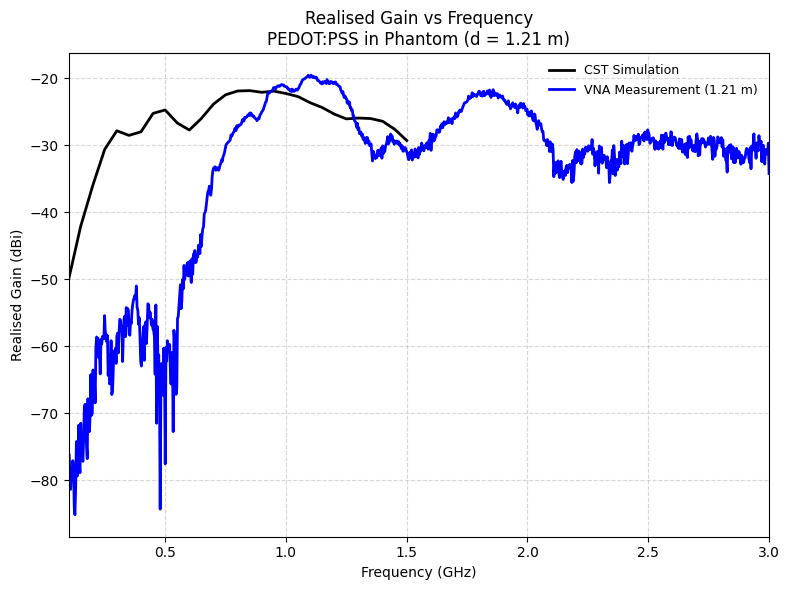

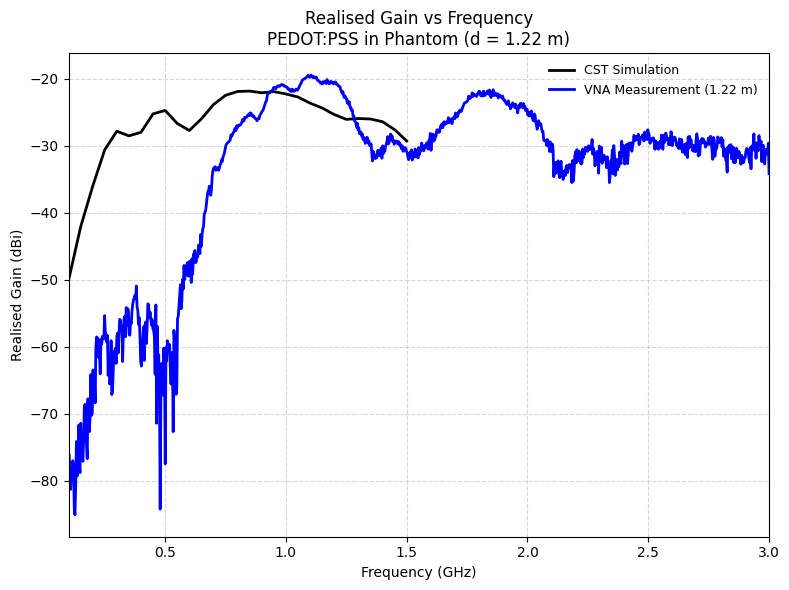

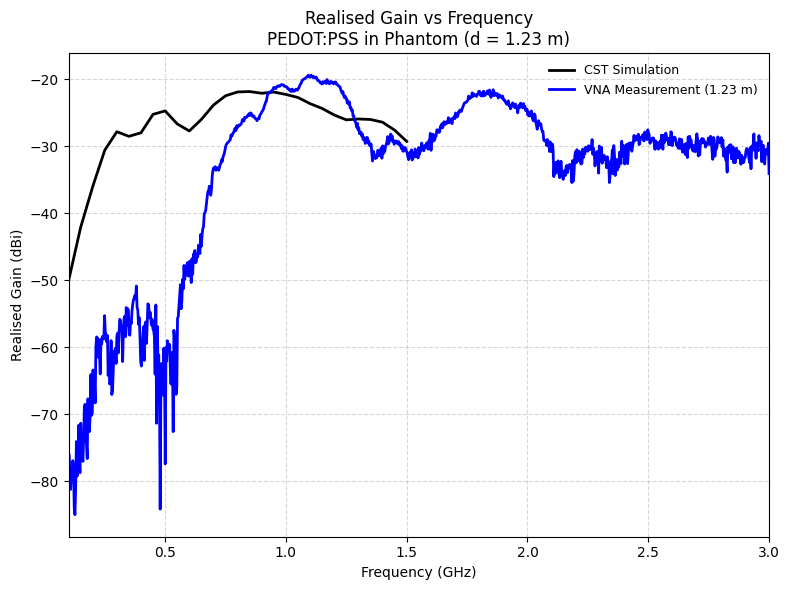

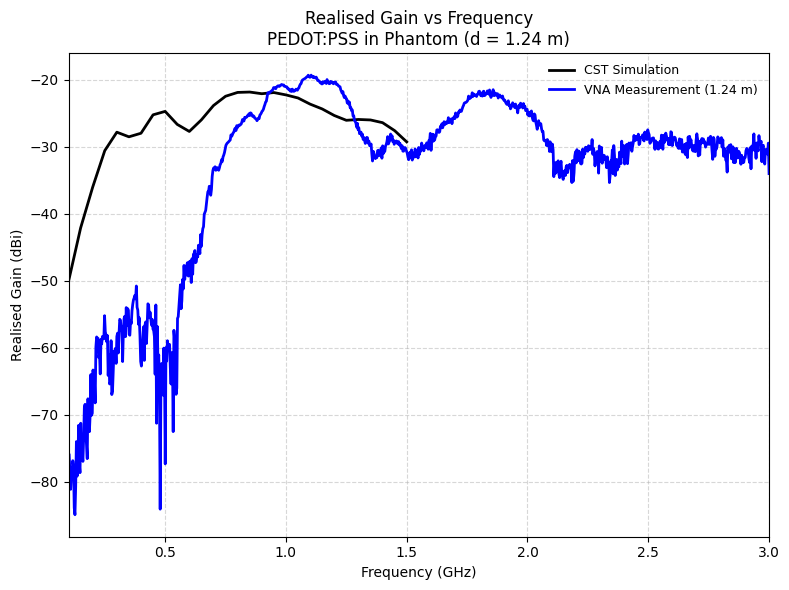

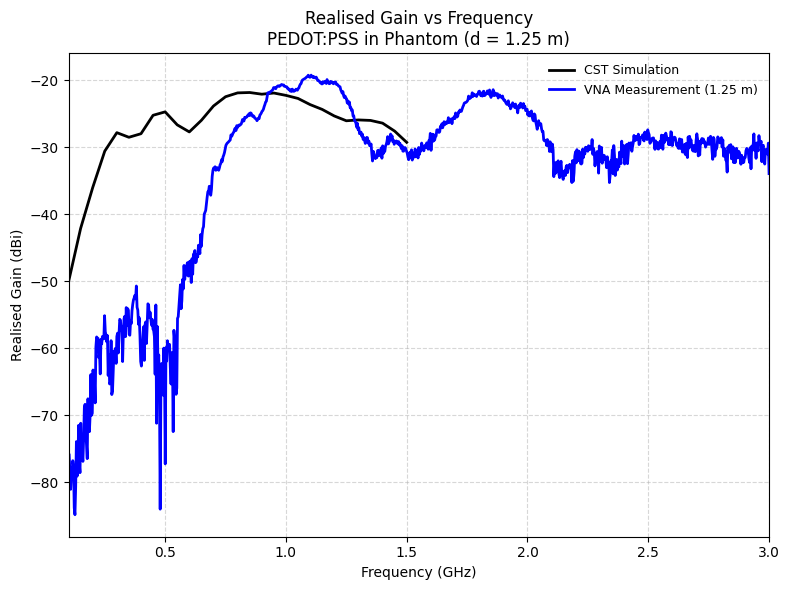

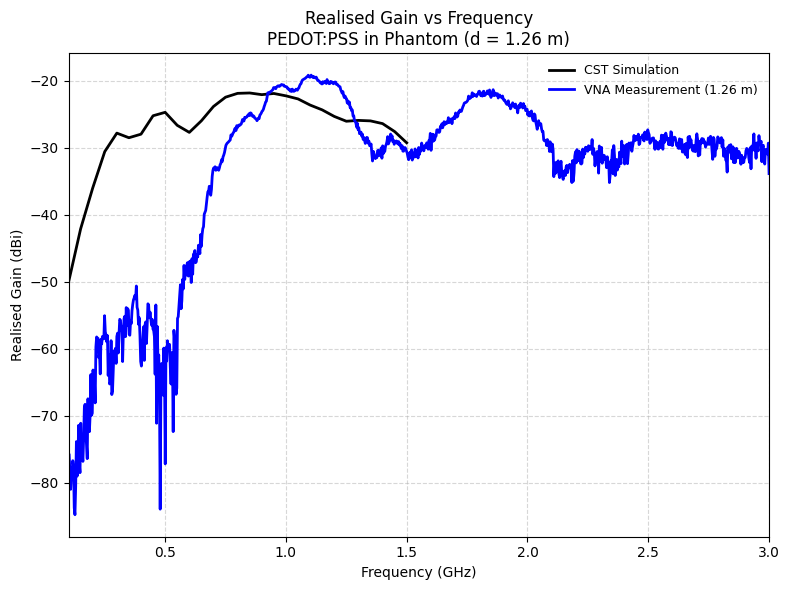

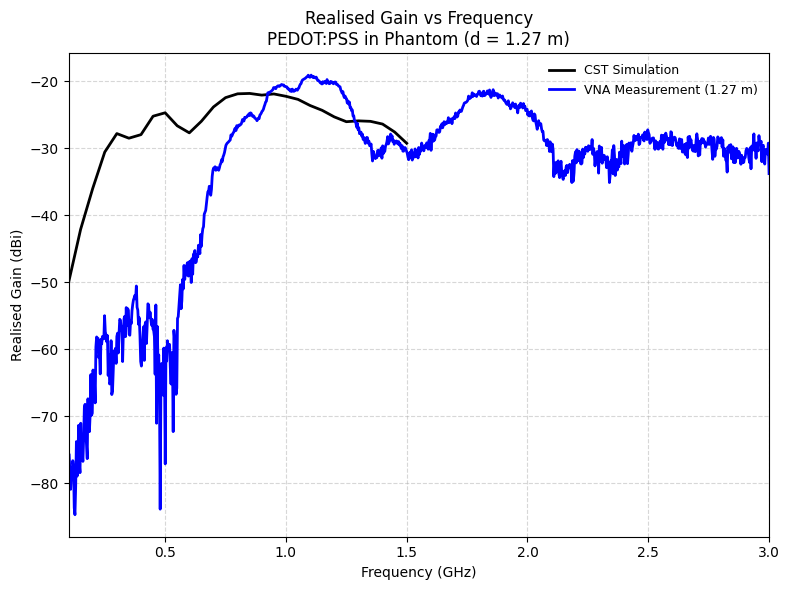

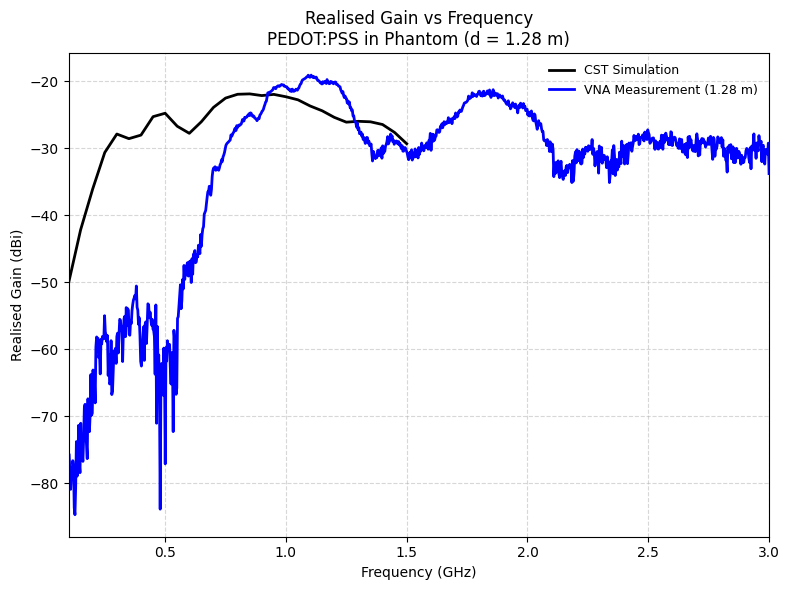

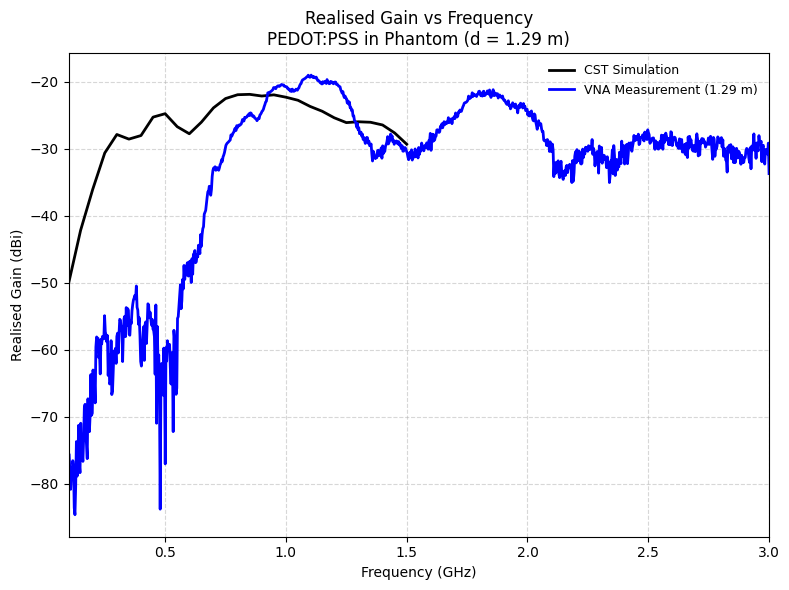

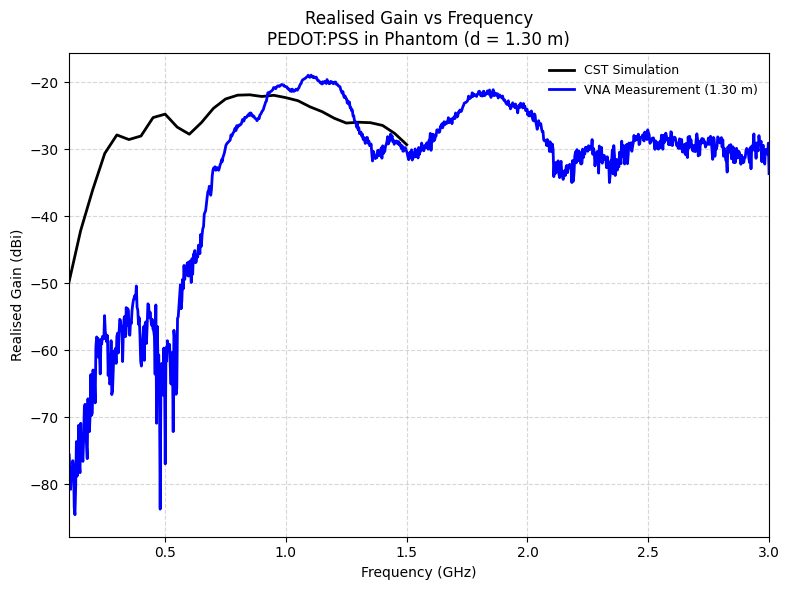

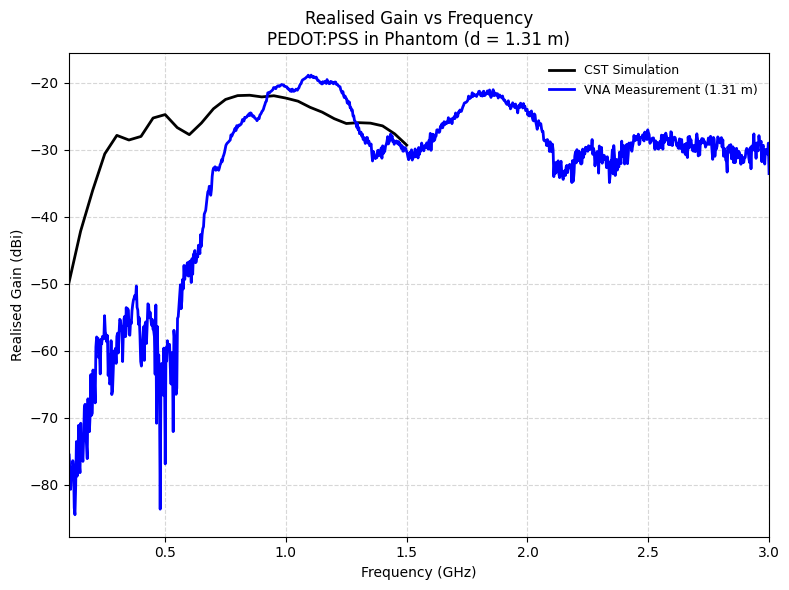

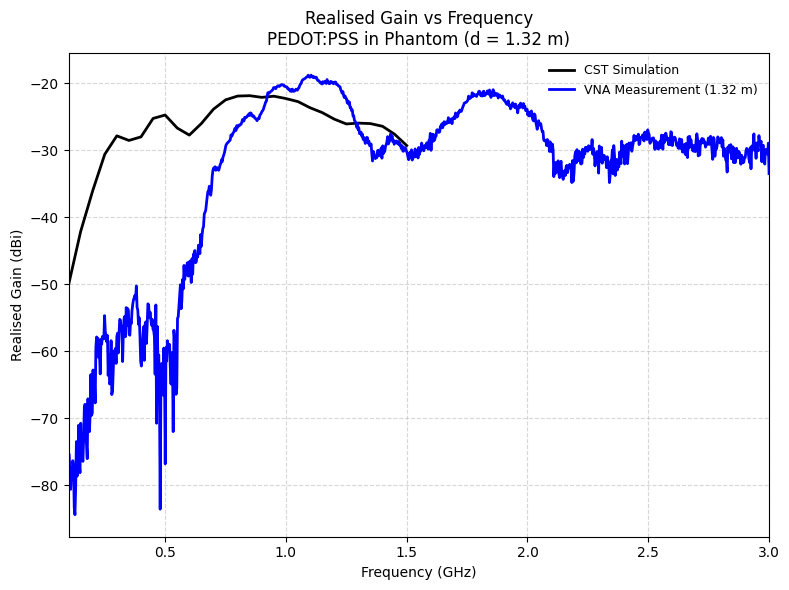

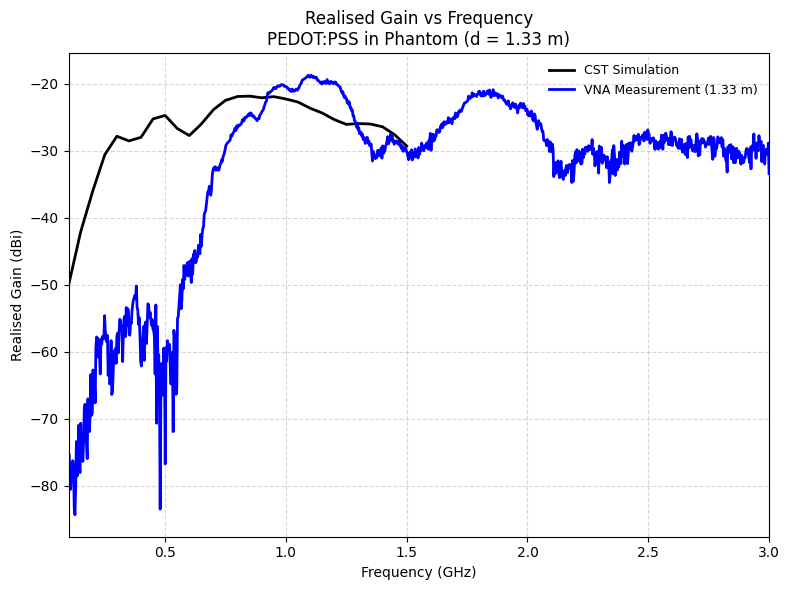

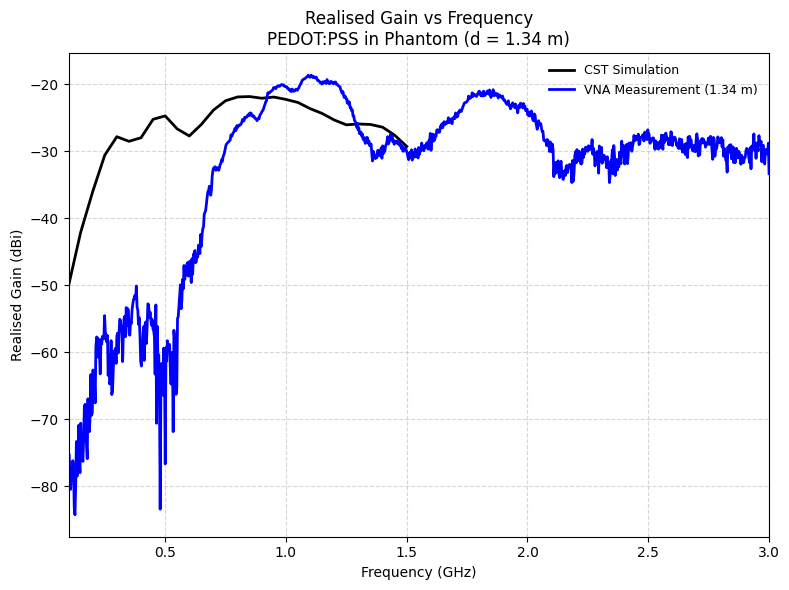

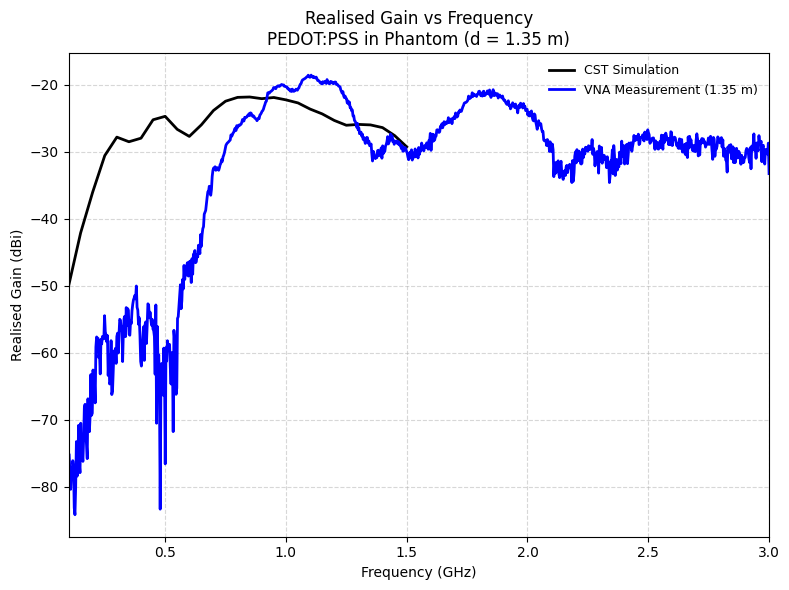

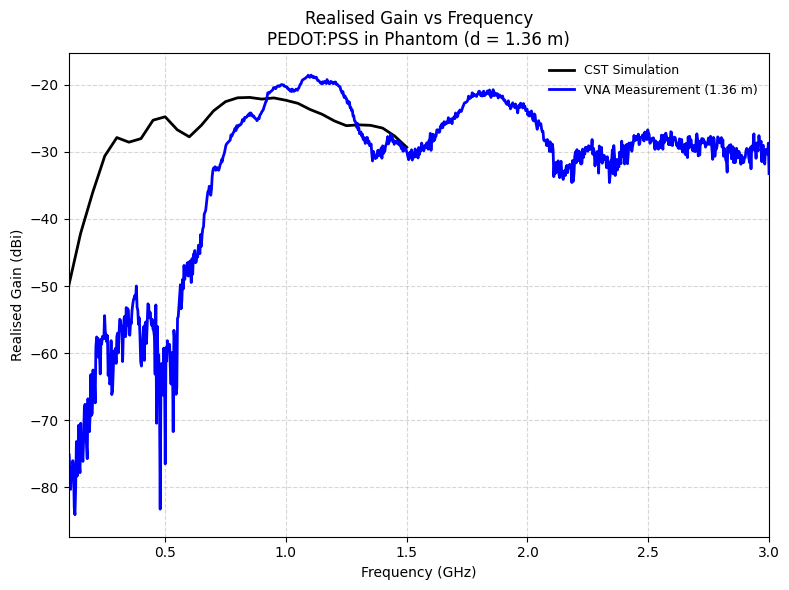

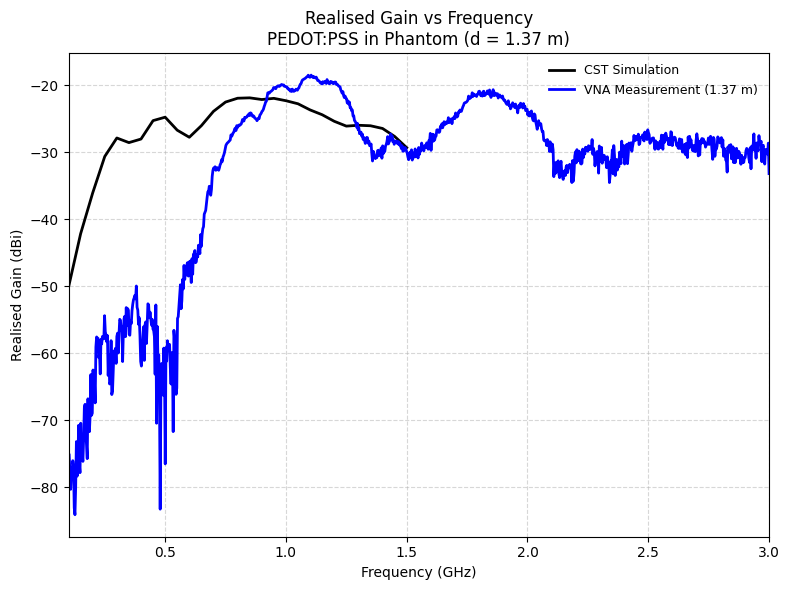

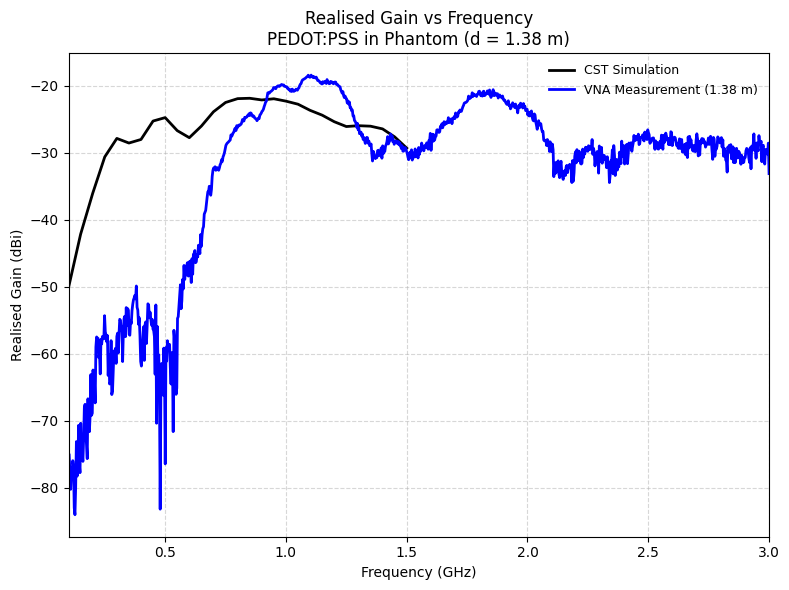

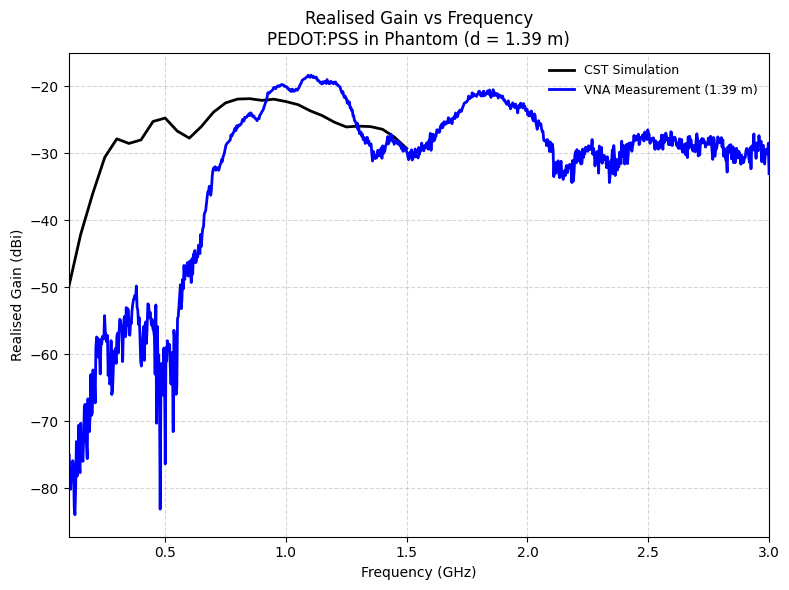

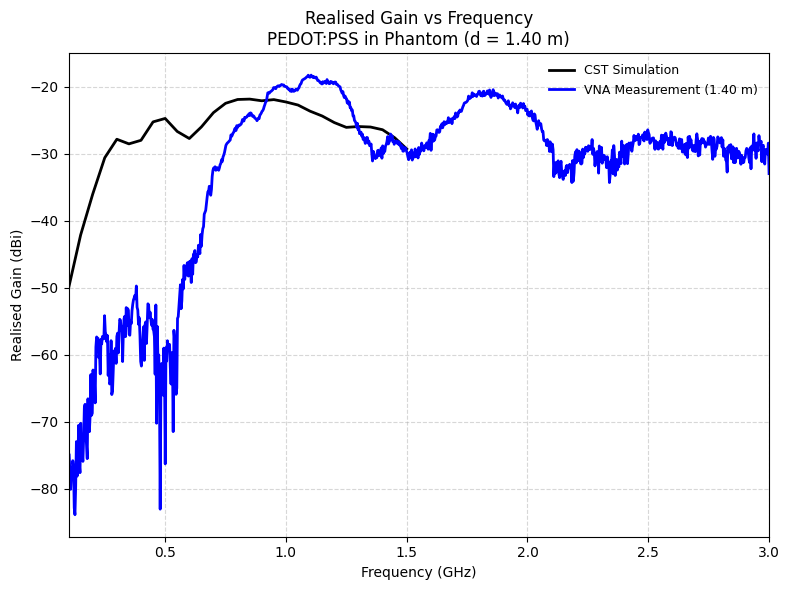

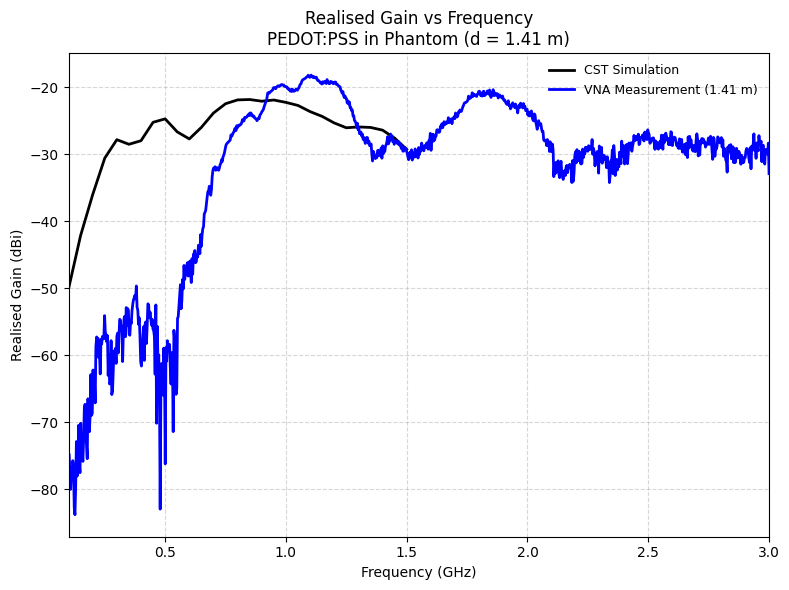

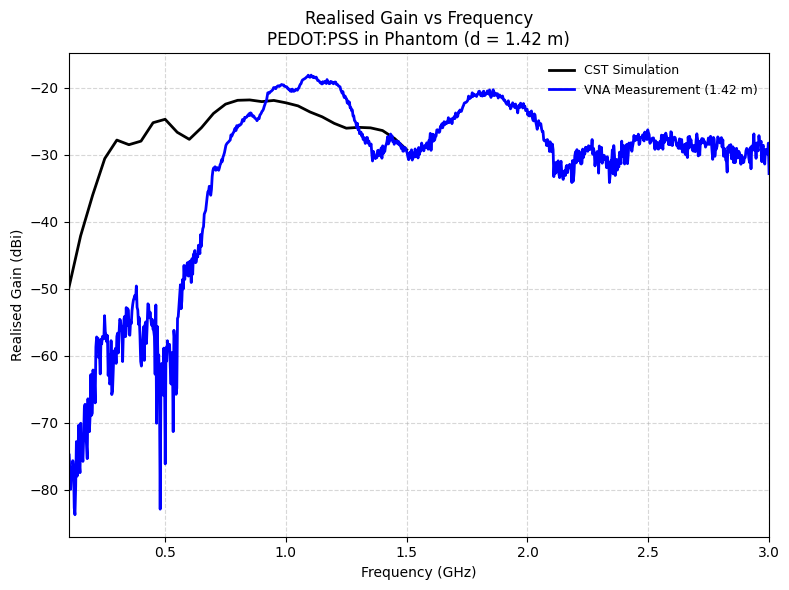

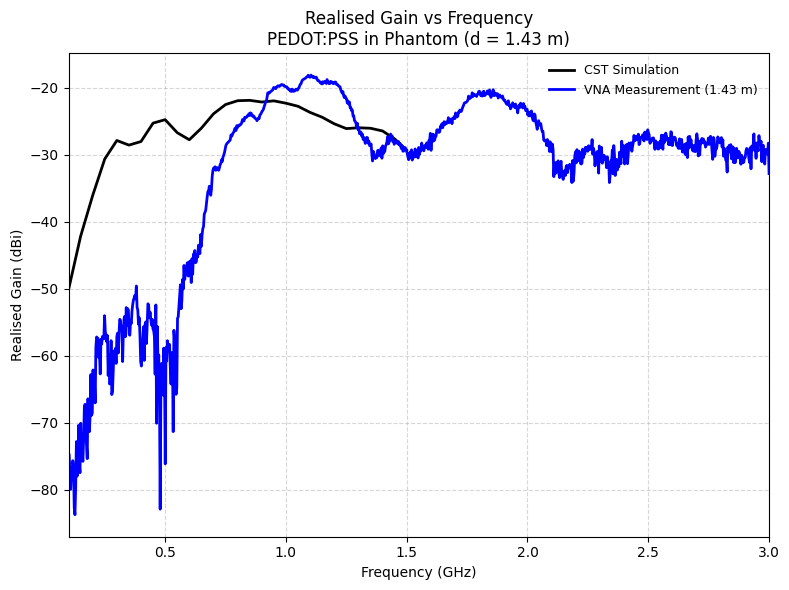

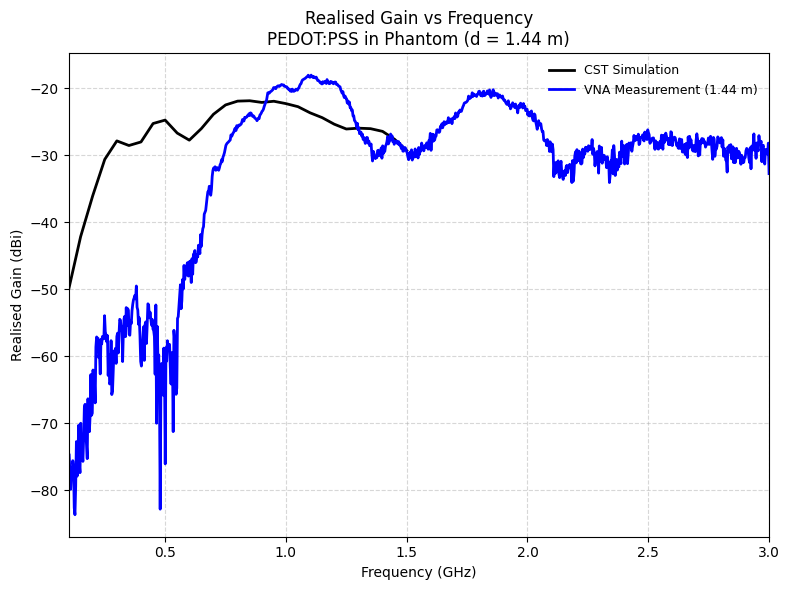

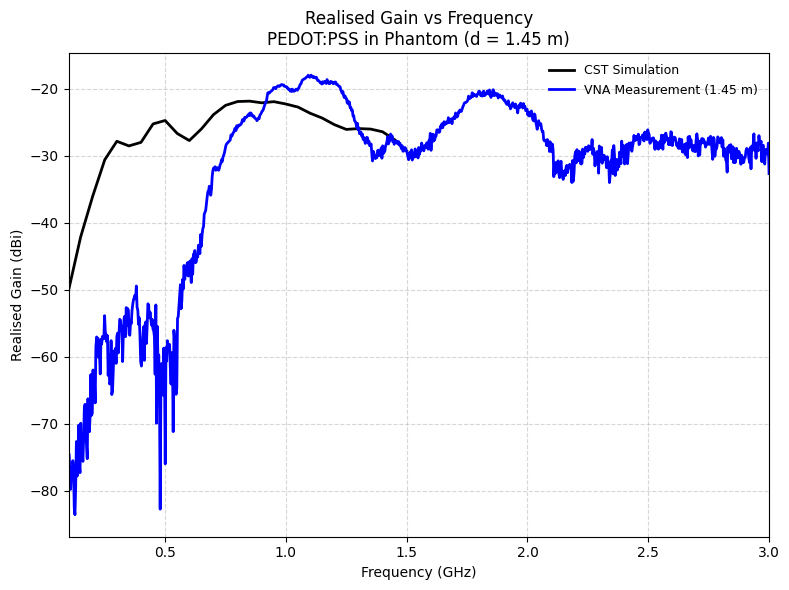

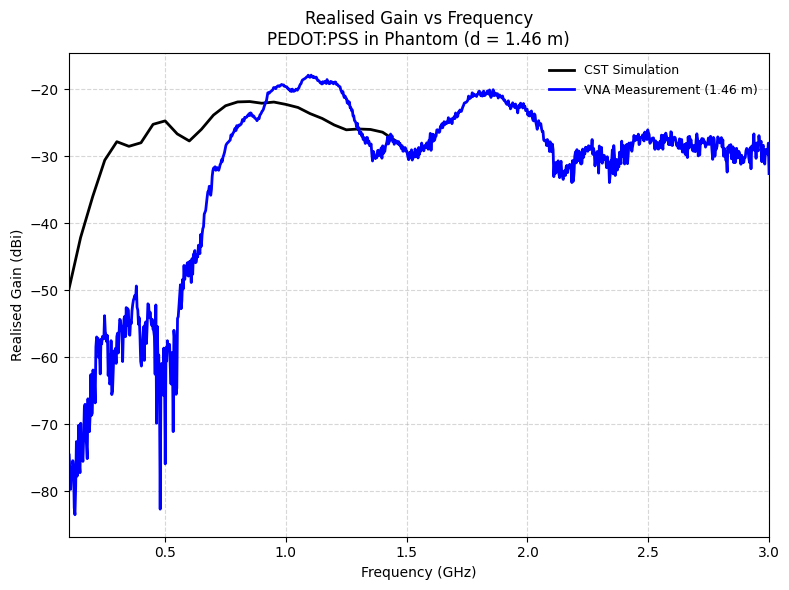

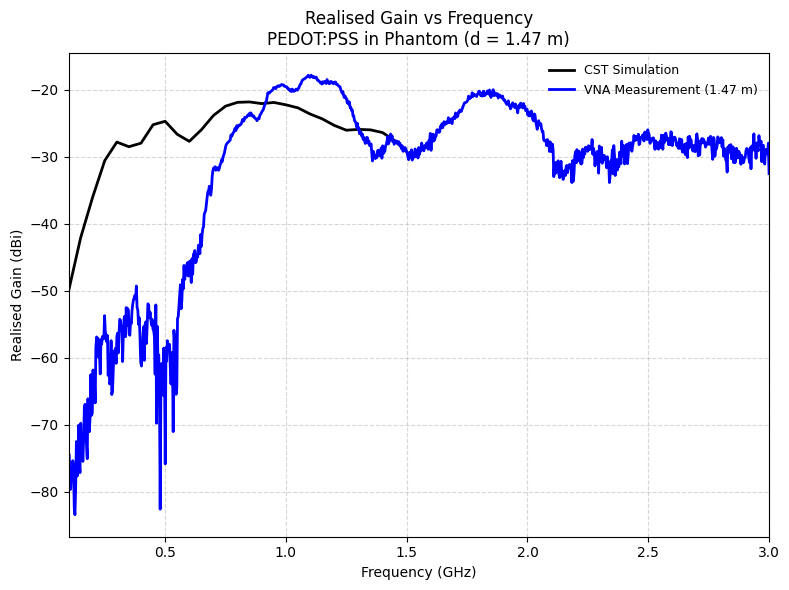

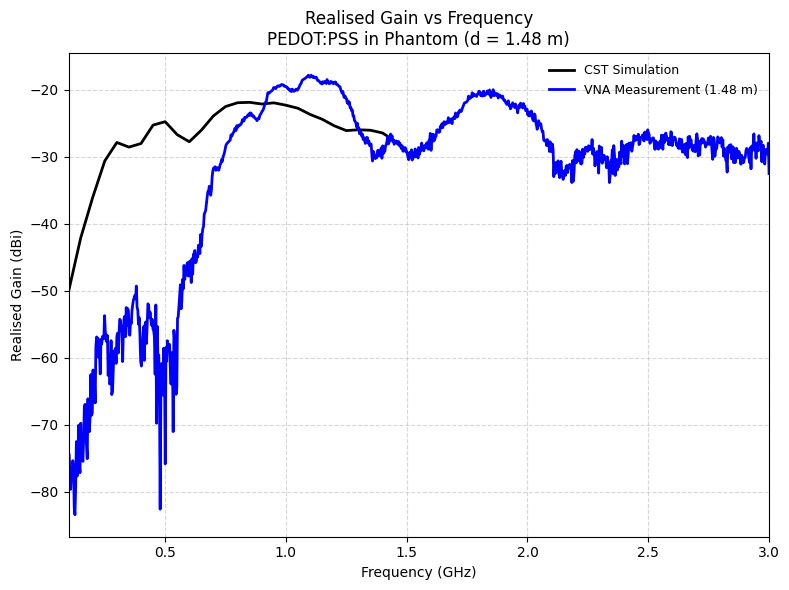

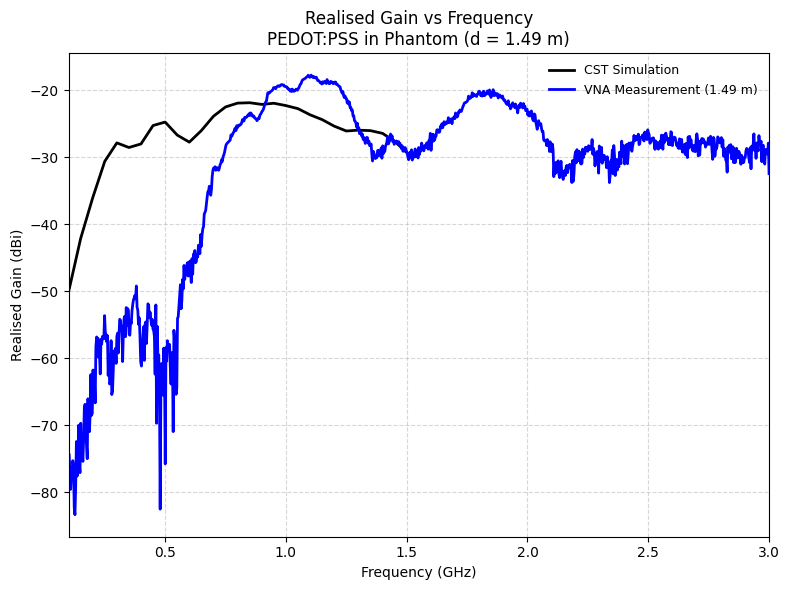

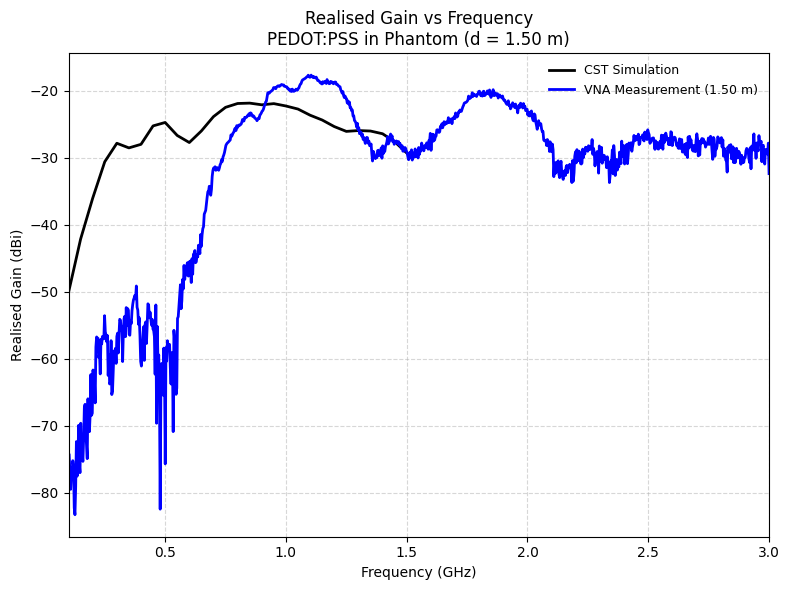

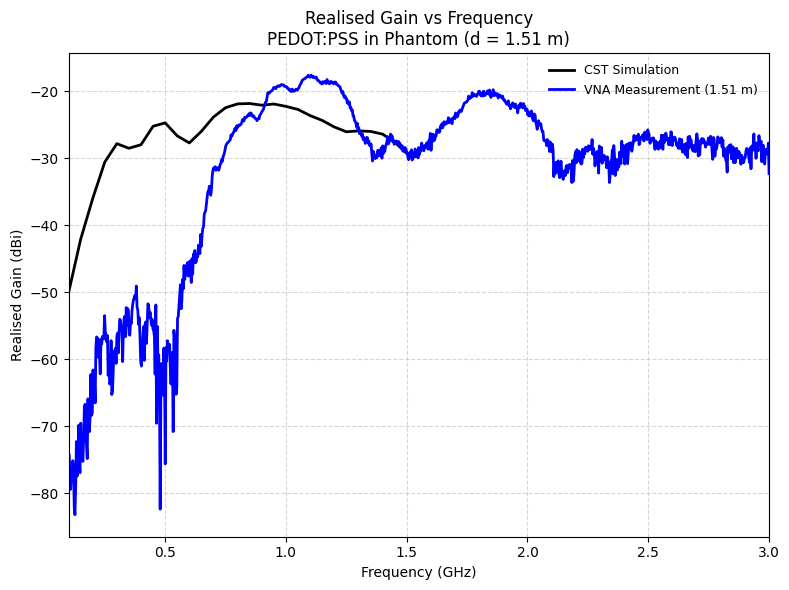

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.51m.png


In [ ]:
!pip install scikit-rf
import os
import glob
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LOAD S2P FILE
# ------------------------------------------------
ntwk = rf.Network('pedot_Dipole_F_10M_3000MHz_block sqashed 1.s2p')

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep from 1.20 m to 1.50 m
distances = np.arange(1.20, 1.51, 0.01)

# ------------------------------------------------
# EXTRACT DATA
# ------------------------------------------------
freq = ntwk.f
s21_db = ntwk.s_db[:, 1, 0]

# ------------------------------------------------
# FILTER FREQUENCY RANGE
# ------------------------------------------------
mask = (freq >= 0.1e9) & (freq <= 3e9)
freq = freq[mask]
s21_db = s21_db[mask]

# ------------------------------------------------
# RECEIVED POWER
# ------------------------------------------------
Pr = s21_db

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:

    # Free Space Path Loss
    fspl = (
        20 * np.log10(d)
        + 20 * np.log10(freq)
        + 20 * np.log10(4 * np.pi / c)
    )

    # Calculate Gain
    Gt = Pr - Pt + fspl - Gr

    # ------------------------------------------------
    # CREATE FIGURE
    # ------------------------------------------------
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # VNA Measurement
    plt.plot(
        freq / 1e9,
        Gt,
        color="blue",
        linewidth=2,
        label=f'VNA Measurement ({d:.2f} m)'
    )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 3)

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Realised Gain (dBi)')

    plt.title(
        f'Realised Gain vs Frequency\nPEDOT:PSS in Phantom (d = {d:.2f} m)'
    )

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.legend(fontsize=9, loc='best', frameon=False)

    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
# Get filename without extension
 # title_name = os.path.splitext(os.path.basename(s2p_file))[0]

filename = f"Gain_plot_{title_name}_{d:.2f}m.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {filename}")

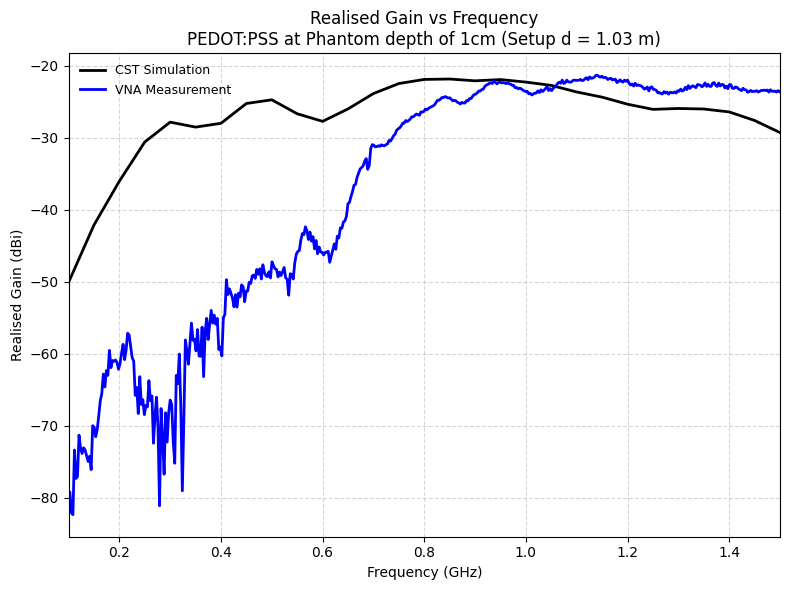

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.03m.png


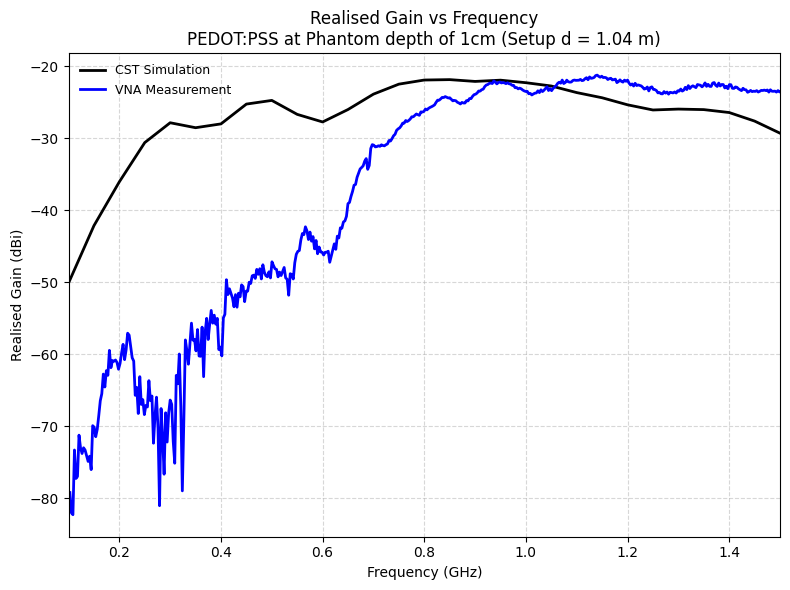

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.04m.png


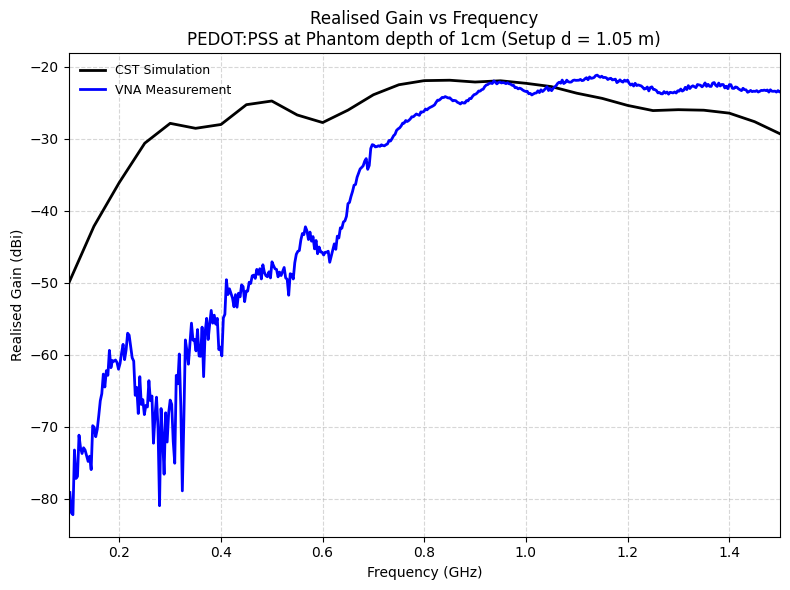

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.05m.png


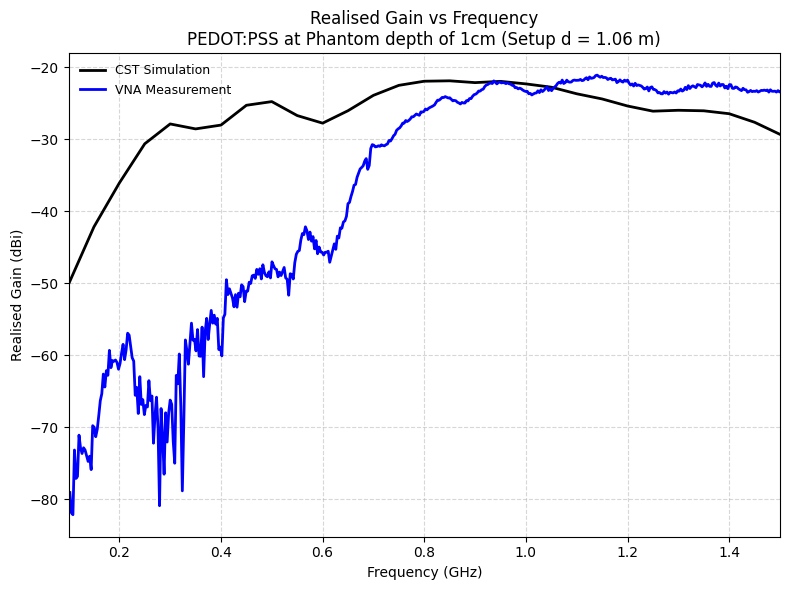

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.06m.png


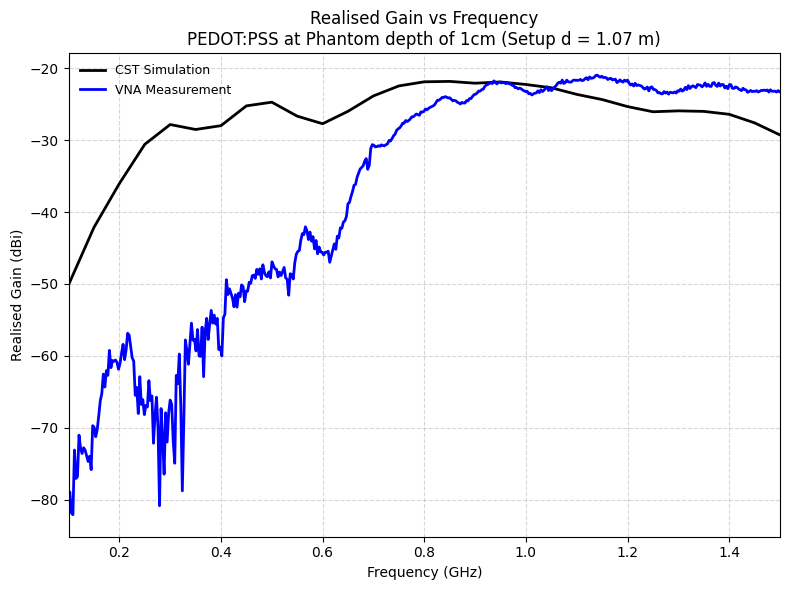

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.07m.png


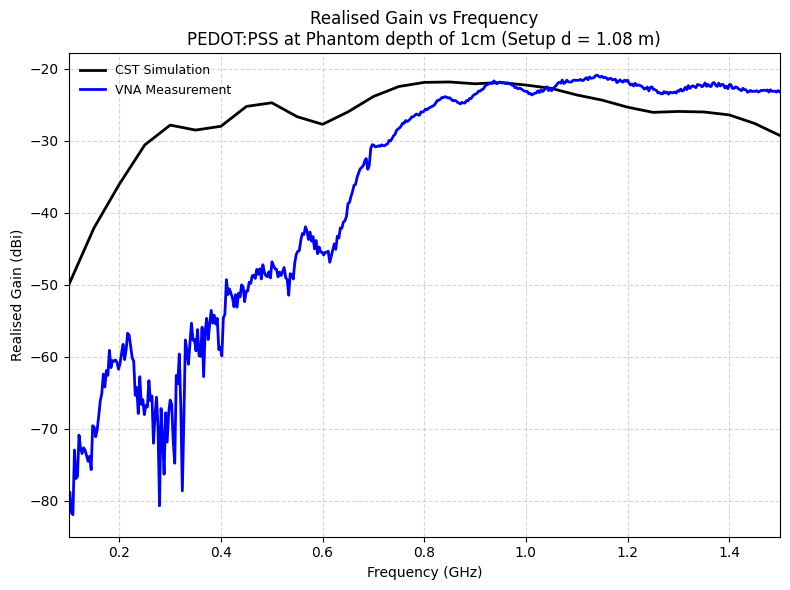

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.08m.png


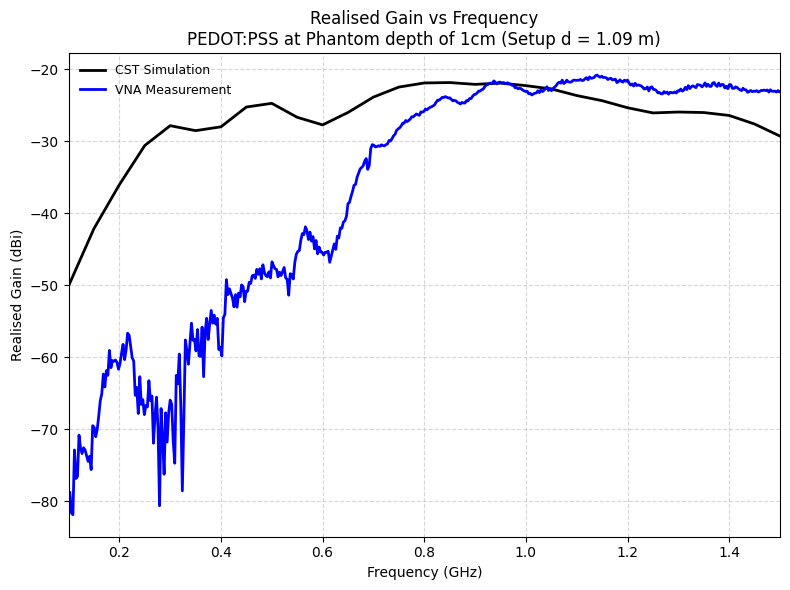

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.09m.png


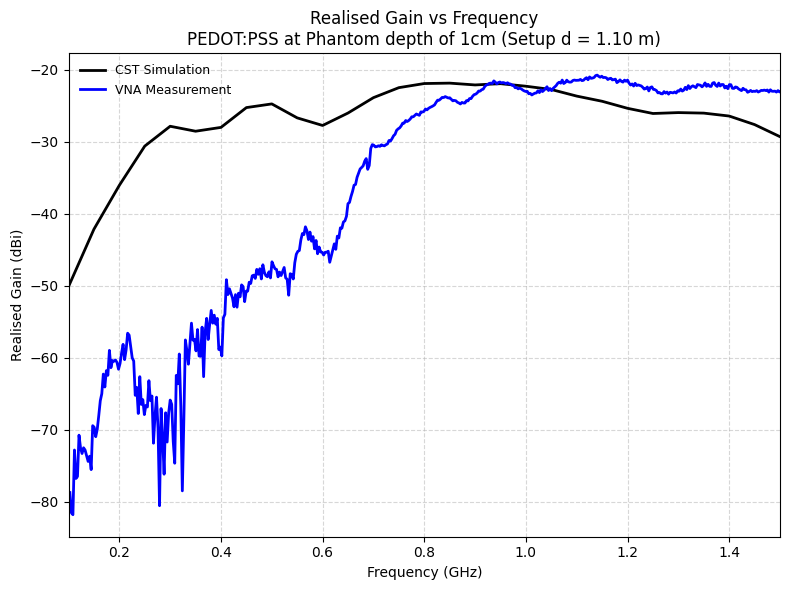

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.10m.png


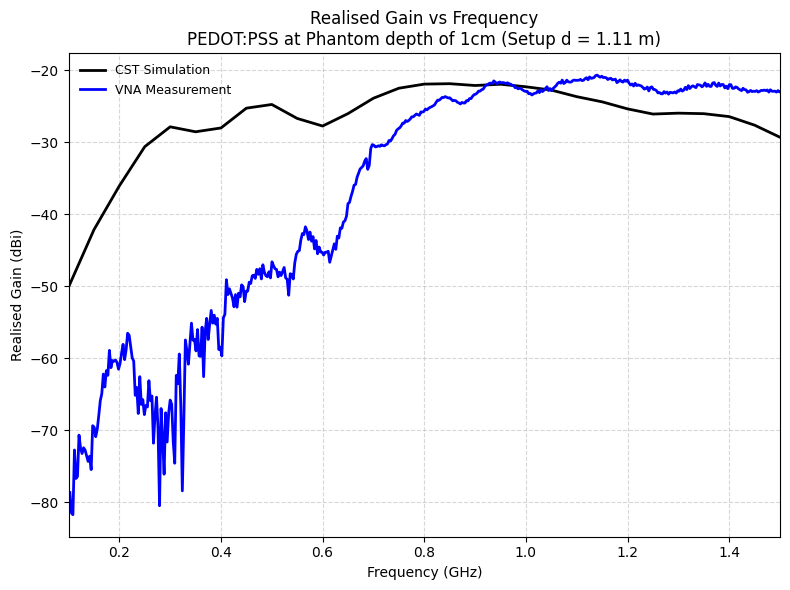

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.11m.png


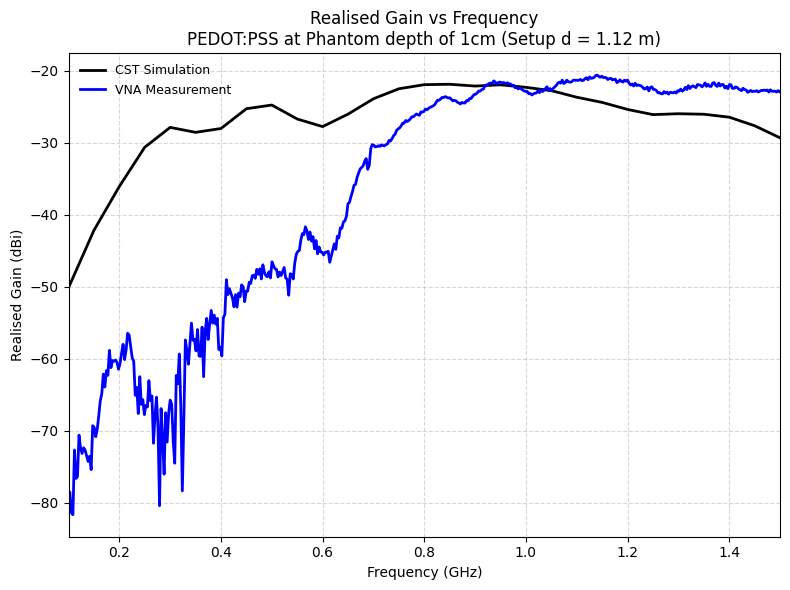

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.12m.png


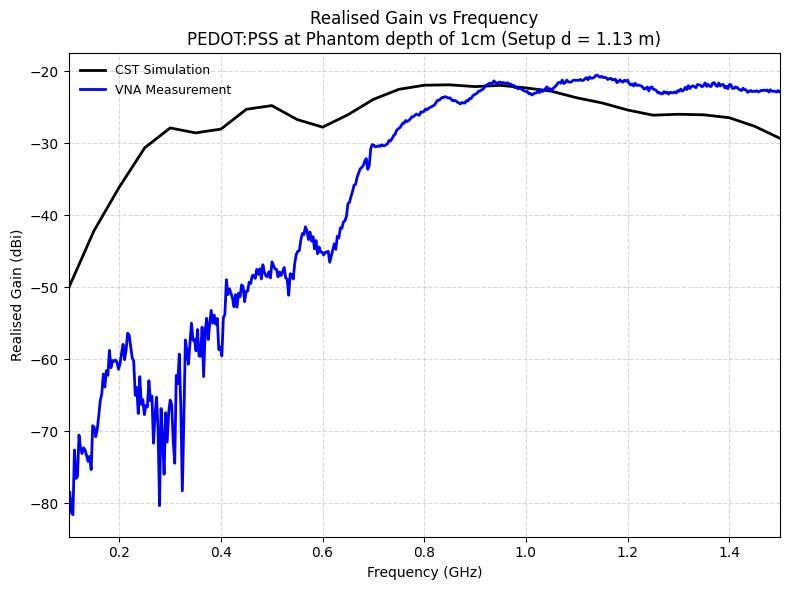

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.13m.png


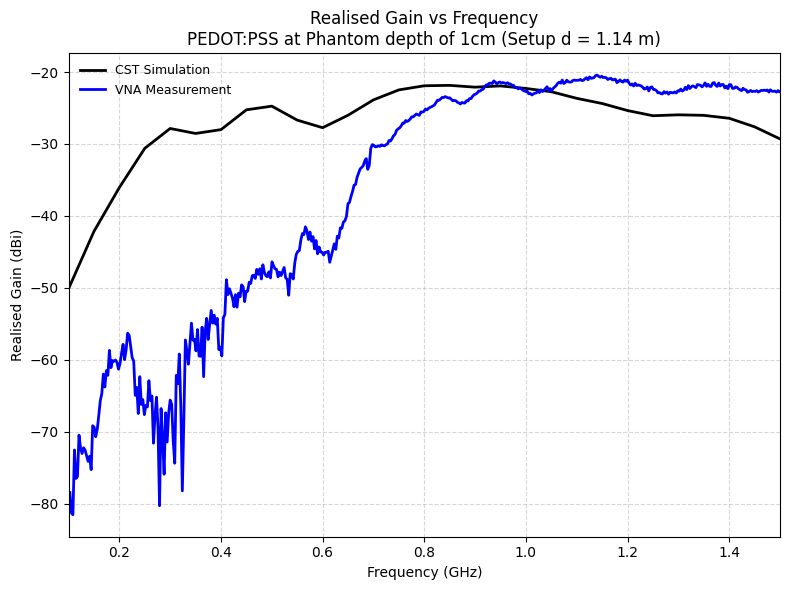

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.14m.png


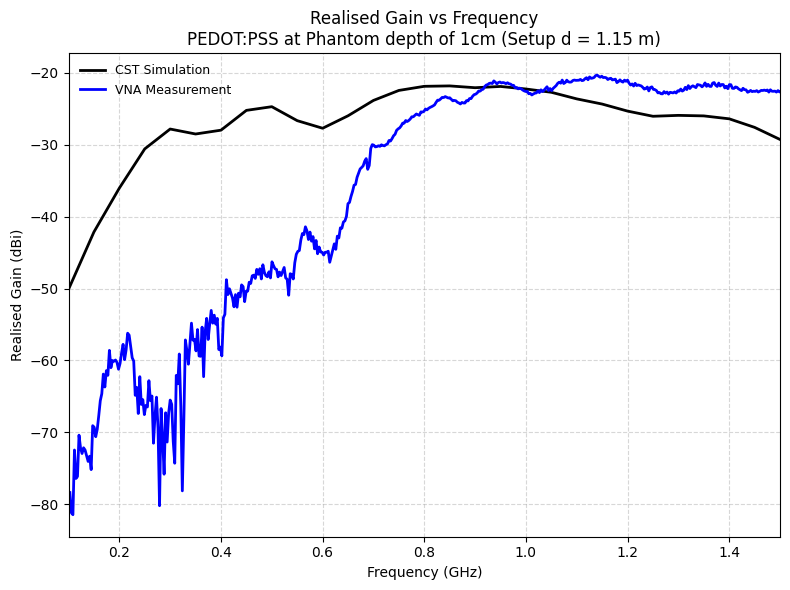

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.15m.png


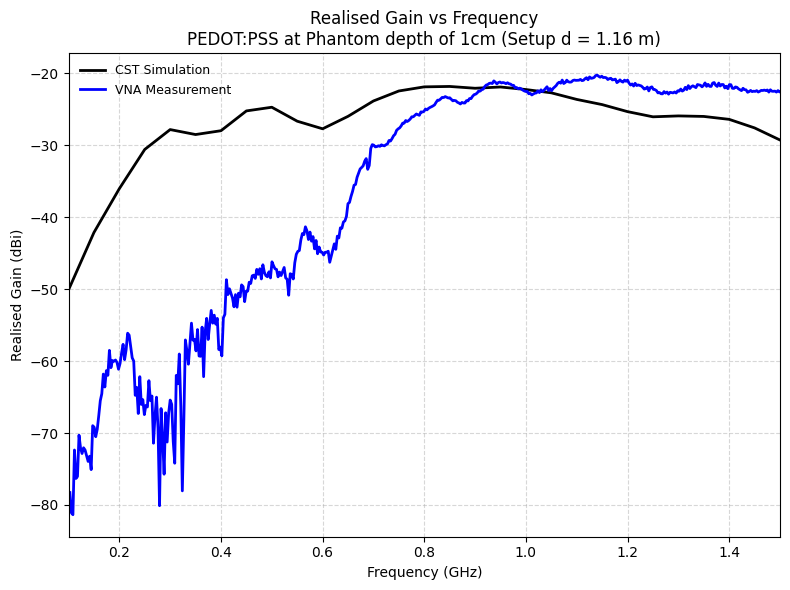

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.16m.png


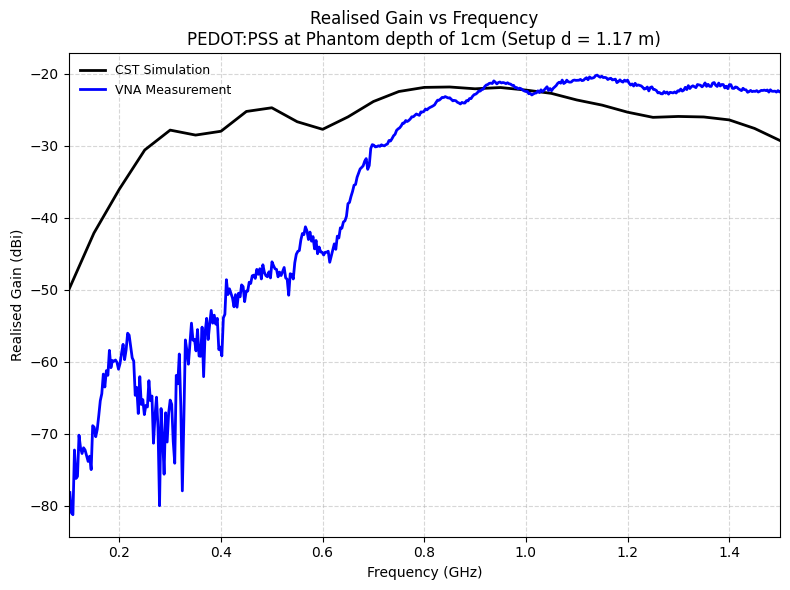

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.17m.png


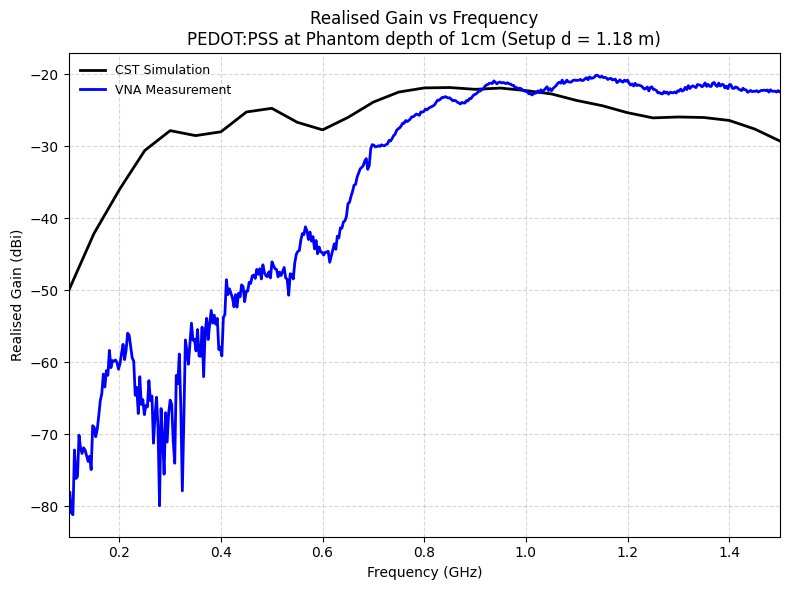

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.18m.png


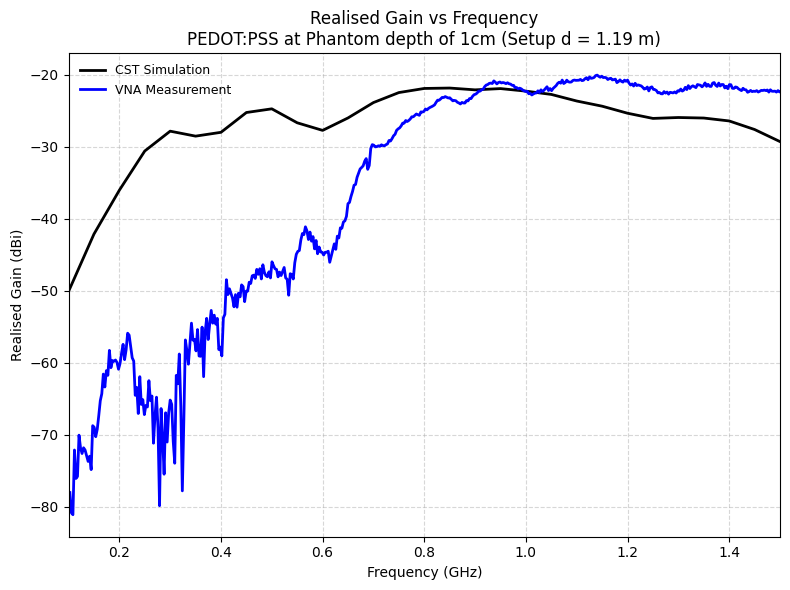

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.19m.png


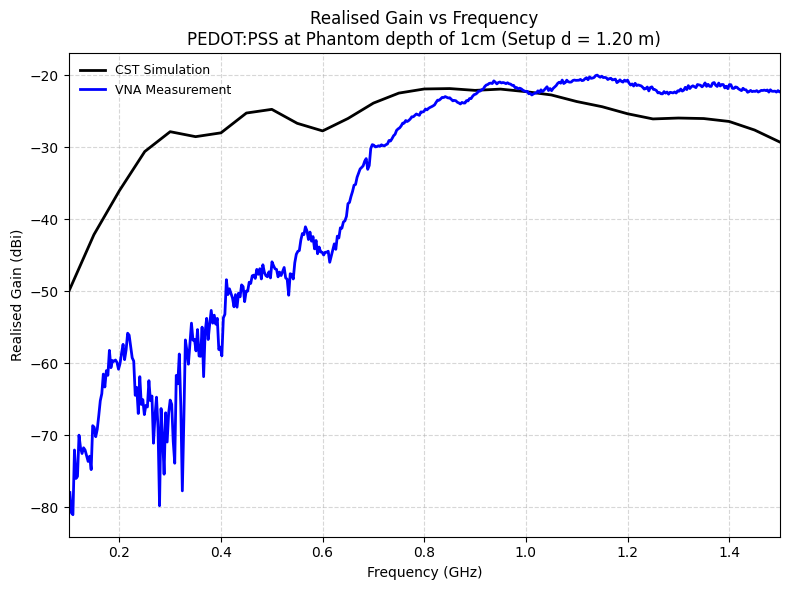

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.20m.png


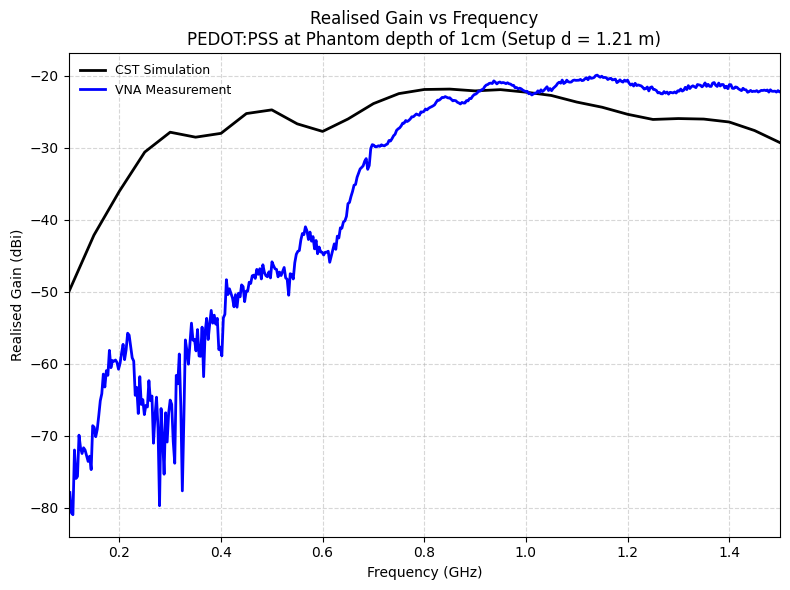

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.21m.png


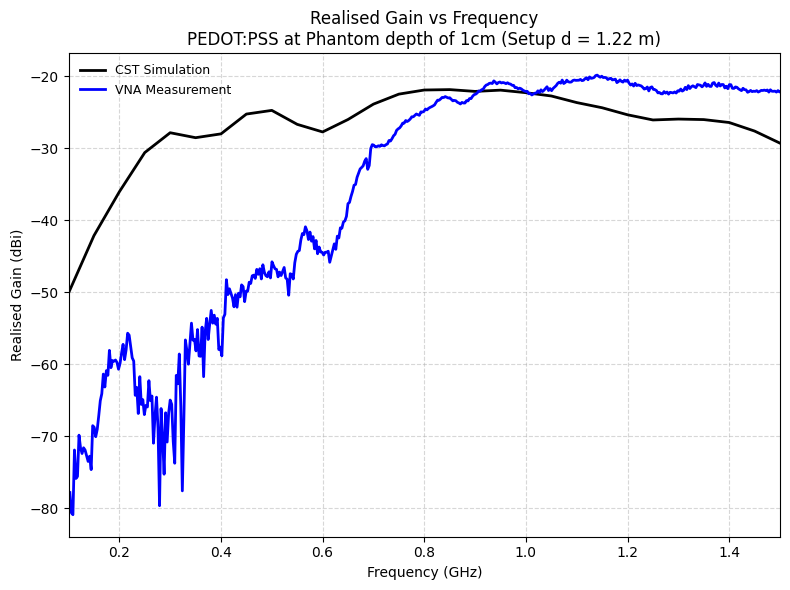

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.22m.png


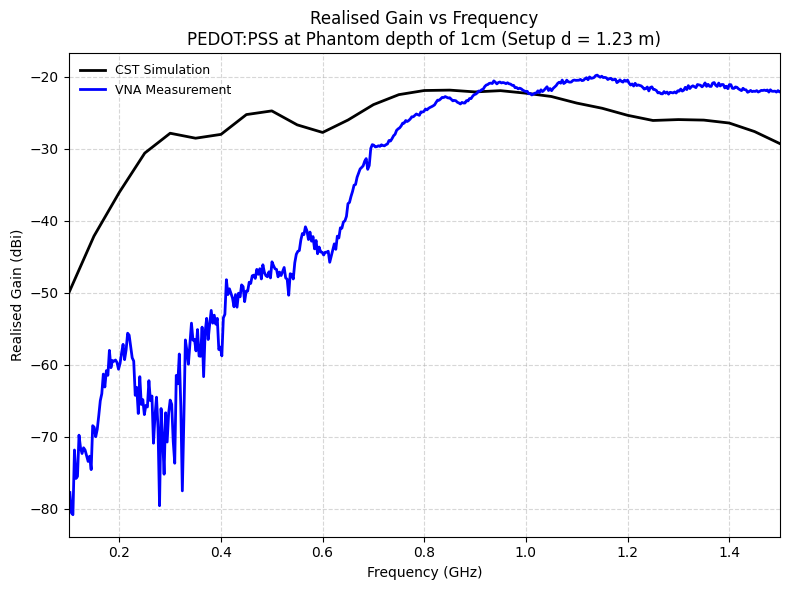

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_1.23m.png


In [ ]:

# --------------------------------------------------------------
# THIN PUSHED EDGE
#----------------------------------------------------------------


!pip install -q scikit-rf

import os
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LOAD S2P FILE
# ------------------------------------------------
s2p_file = "pedot_Dipole_F_10M_3000MHz_thin_pushed_edge.s2p"
ntwk = rf.Network(s2p_file)

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep from 1.20 m to 1.50 m
distances = np.arange(1.22, 1.24, 0.01)

# ------------------------------------------------
# EXTRACT DATA
# ------------------------------------------------
freq = ntwk.f
s21_db = ntwk.s_db[:, 1, 0]

# ------------------------------------------------
# FILTER FREQUENCY RANGE
# ------------------------------------------------
mask = (freq >= 0.1e9) & (freq <= 3e9)
freq = freq[mask]
s21_db = s21_db[mask]

# ------------------------------------------------
# RECEIVED POWER
# ------------------------------------------------
Pr = s21_db

# Get filename without extension
title_name = os.path.splitext(os.path.basename(s2p_file))[0]

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:
    # Free Space Path Loss
    fspl = (
        20 * np.log10(d)
        + 20 * np.log10(freq)
        + 20 * np.log10(4 * np.pi / c)
    )

    # Calculate Gain
    Gt = Pr - Pt + fspl - Gr

    # ------------------------------------------------
    # CREATE FIGURE
    # ------------------------------------------------
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # VNA Measurement
    plt.plot(
        freq / 1e9,
        Gt,
        color="blue",
        linewidth=2,
        label=f"VNA Measurement"
    )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 1.5)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Realised Gain (dBi)")
    plt.title(f"Realised Gain vs Frequency\nPEDOT:PSS at Phantom depth of 1cm (Setup d = {d:.2f} m)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=9, loc="best", frameon=False)
    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
    filename = f"Gain_plot_{title_name}_{d:.2f}m.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {filename}")

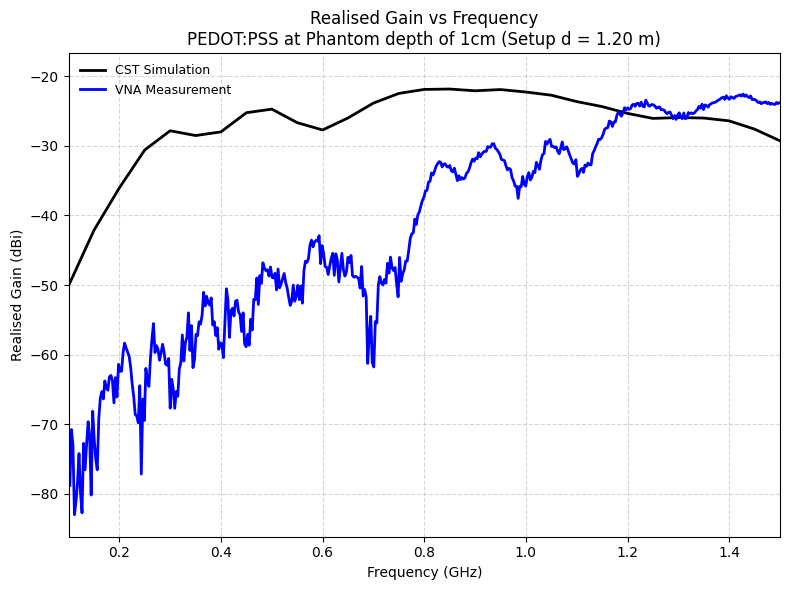

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_1.20m.png


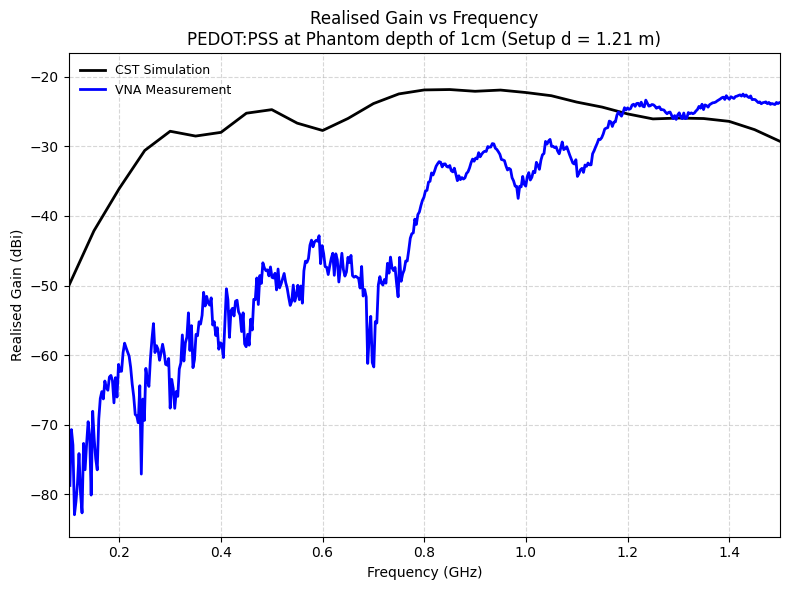

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_1.21m.png


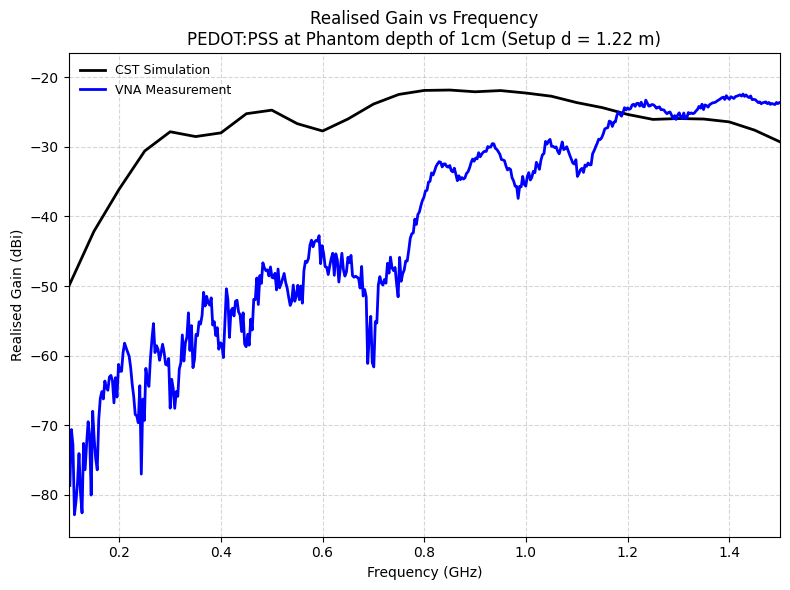

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thin_pushed_1.22m.png


In [ ]:
#----------------------------------------------
# THIN PUSHED
# ----------------------------------------------

!pip install -q scikit-rf

import os
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LOAD S2P FILE
# ------------------------------------------------
s2p_file = "pedot_Dipole_F_10M_3000MHz_thin_pushed.s2p"
ntwk = rf.Network(s2p_file)

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep from 1.20 m to 1.50 m
distances = np.arange(1.20, 1.22, 0.01)

# ------------------------------------------------
# EXTRACT DATA
# ------------------------------------------------
freq = ntwk.f
s21_db = ntwk.s_db[:, 1, 0]

# ------------------------------------------------
# FILTER FREQUENCY RANGE
# ------------------------------------------------
mask = (freq >= 0.1e9) & (freq <= 3e9)
freq = freq[mask]
s21_db = s21_db[mask]

# ------------------------------------------------
# RECEIVED POWER
# ------------------------------------------------
Pr = s21_db

# Get filename without extension
title_name = os.path.splitext(os.path.basename(s2p_file))[0]

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:
    # Free Space Path Loss
    fspl = (
        20 * np.log10(d)
        + 20 * np.log10(freq)
        + 20 * np.log10(4 * np.pi / c)
    )

    # Calculate Gain
    Gt = Pr - Pt + fspl - Gr

    # ------------------------------------------------
    # CREATE FIGURE
    # ------------------------------------------------
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # VNA Measurement
    plt.plot(
        freq / 1e9,
        Gt,
        color="blue",
        linewidth=2,
        label=f"VNA Measurement"
    )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 1.5)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Realised Gain (dBi)")
    plt.title(f"Realised Gain vs Frequency\nPEDOT:PSS at Phantom depth of 1cm (Setup d = {d:.2f} m)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=9, loc="best", frameon=False)
    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
    filename = f"Gain_plot_{title_name}_{d:.2f}m.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {filename}")

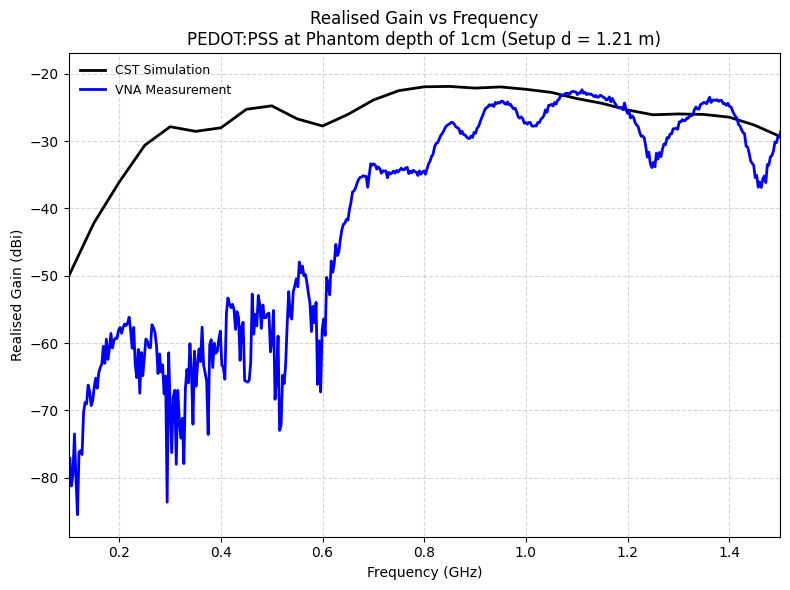

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thick block sqashed 1_1.21m.png


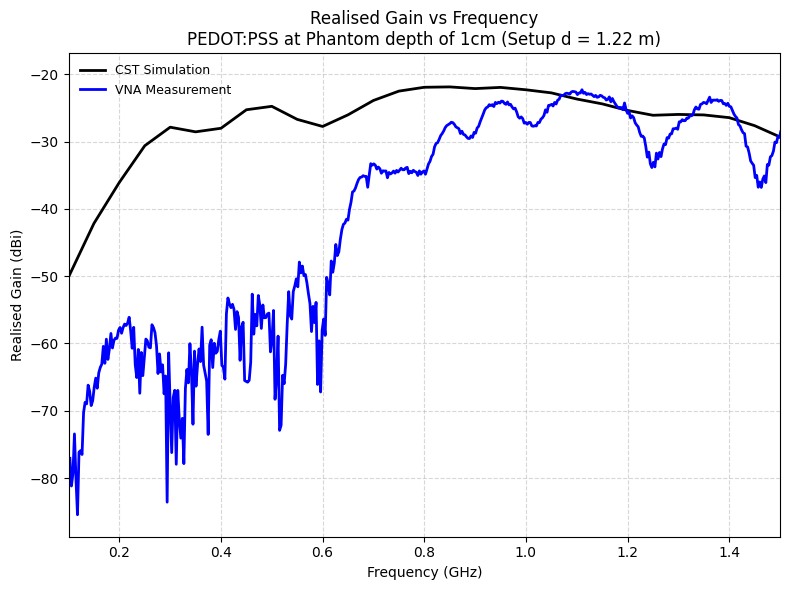

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thick block sqashed 1_1.22m.png


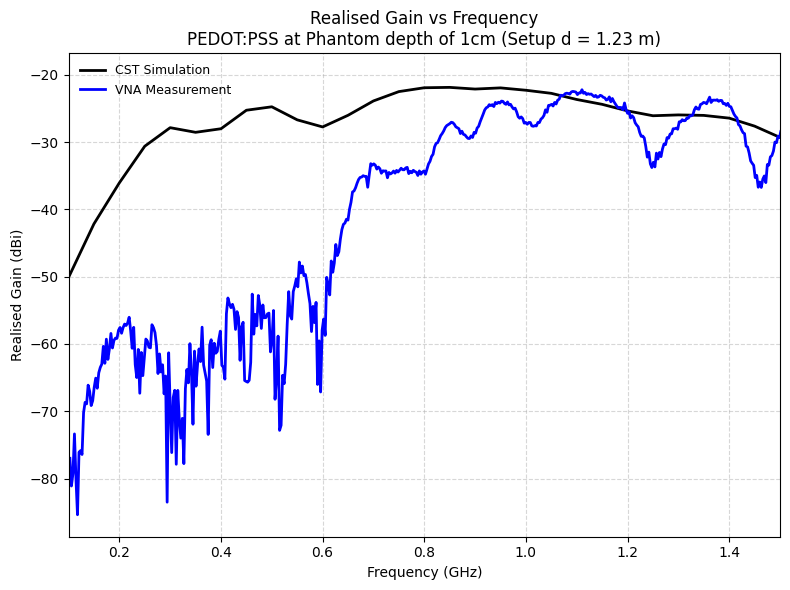

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_thick block sqashed 1_1.23m.png


In [ ]:
#----------------------------------------------
# THICK BLOCK SQASHED 1
# ----------------------------------------------

!pip install -q scikit-rf

import os
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LOAD S2P FILE
# ------------------------------------------------
s2p_file = "pedot_Dipole_F_10M_3000MHz_thick block sqashed 1.s2p"
ntwk = rf.Network(s2p_file)

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep from 1.20 m to 1.50 m
distances = np.arange(1.21, 1.23, 0.01)

# ------------------------------------------------
# EXTRACT DATA
# ------------------------------------------------
freq = ntwk.f
s21_db = ntwk.s_db[:, 1, 0]

# ------------------------------------------------
# FILTER FREQUENCY RANGE
# ------------------------------------------------
mask = (freq >= 0.1e9) & (freq <= 3e9)
freq = freq[mask]
s21_db = s21_db[mask]

# ------------------------------------------------
# RECEIVED POWER
# ------------------------------------------------
Pr = s21_db

# Get filename without extension
title_name = os.path.splitext(os.path.basename(s2p_file))[0]

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:
    # Free Space Path Loss
    fspl = (
        20 * np.log10(d)
        + 20 * np.log10(freq)
        + 20 * np.log10(4 * np.pi / c)
    )

    # Calculate Gain
    Gt = Pr - Pt + fspl - Gr

    # ------------------------------------------------
    # CREATE FIGURE
    # ------------------------------------------------
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # VNA Measurement
    plt.plot(
        freq / 1e9,
        Gt,
        color="blue",
        linewidth=2,
        label=f"VNA Measurement"
    )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 1.5)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Realised Gain (dBi)")
    plt.title(f"Realised Gain vs Frequency\nPEDOT:PSS at Phantom depth of 1cm (Setup d = {d:.2f} m)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=9, loc="best", frameon=False)
    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
    filename = f"Gain_plot_{title_name}_{d:.2f}m.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {filename}")

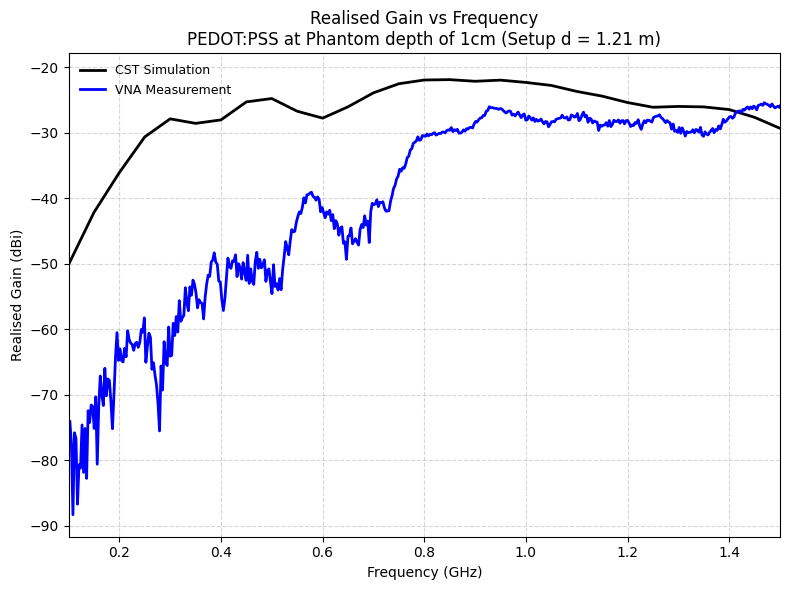

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_block sqashed 2_1.21m.png


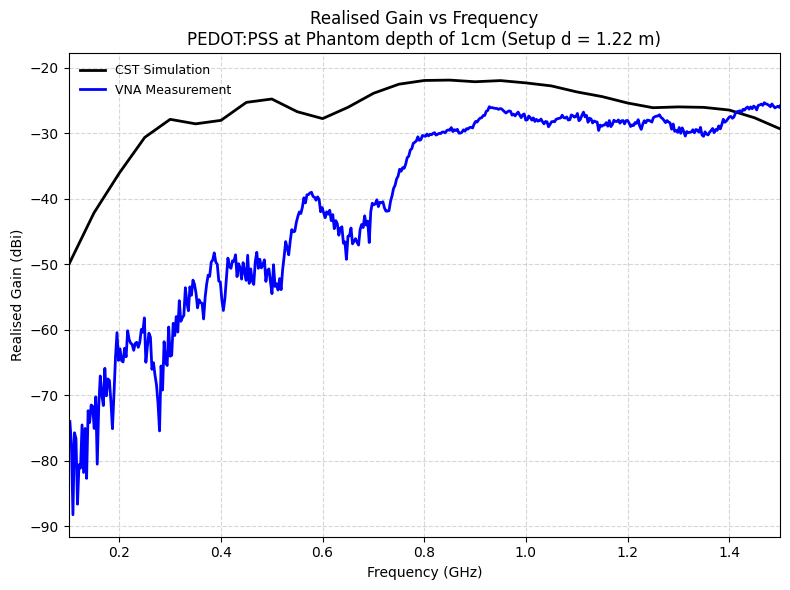

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_block sqashed 2_1.22m.png


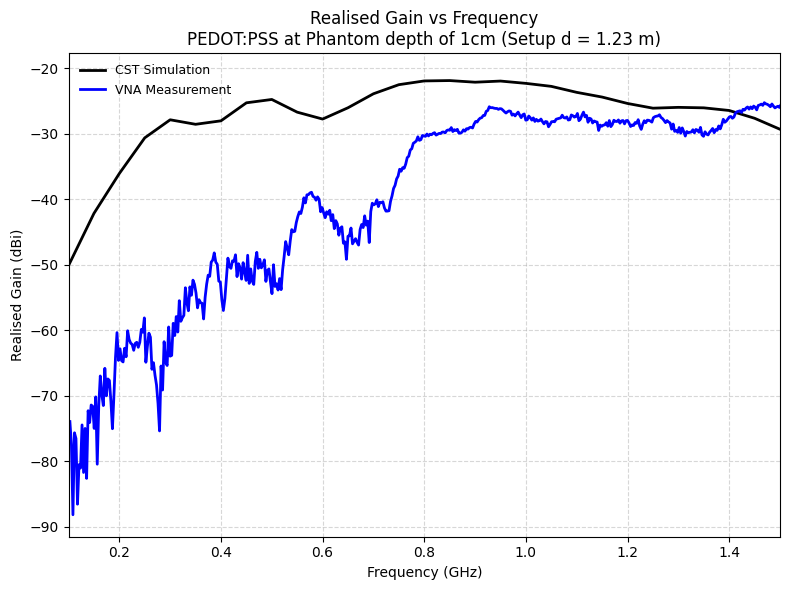

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_block sqashed 2_1.23m.png


In [ ]:
#----------------------------------------------
# BLOCK SQASHED 2
# ----------------------------------------------

!pip install -q scikit-rf

import os
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LOAD S2P FILE
# ------------------------------------------------
s2p_file = "pedot_Dipole_F_10M_3000MHz_block sqashed 2.s2p"
ntwk = rf.Network(s2p_file)

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep from 1.20 m to 1.50 m
distances = np.arange(1.21, 1.23, 0.01)

# ------------------------------------------------
# EXTRACT DATA
# ------------------------------------------------
freq = ntwk.f
s21_db = ntwk.s_db[:, 1, 0]

# ------------------------------------------------
# FILTER FREQUENCY RANGE
# ------------------------------------------------
mask = (freq >= 0.1e9) & (freq <= 3e9)
freq = freq[mask]
s21_db = s21_db[mask]

# ------------------------------------------------
# RECEIVED POWER
# ------------------------------------------------
Pr = s21_db

# Get filename without extension
title_name = os.path.splitext(os.path.basename(s2p_file))[0]

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:
    # Free Space Path Loss
    fspl = (
        20 * np.log10(d)
        + 20 * np.log10(freq)
        + 20 * np.log10(4 * np.pi / c)
    )

    # Calculate Gain
    Gt = Pr - Pt + fspl - Gr

    # ------------------------------------------------
    # CREATE FIGURE
    # ------------------------------------------------
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # VNA Measurement
    plt.plot(
        freq / 1e9,
        Gt,
        color="blue",
        linewidth=2,
        label=f"VNA Measurement"
    )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 1.5)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Realised Gain (dBi)")
    plt.title(f"Realised Gain vs Frequency\nPEDOT:PSS at Phantom depth of 1cm (Setup d = {d:.2f} m)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=9, loc="best", frameon=False)
    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
    filename = f"Gain_plot_{title_name}_{d:.2f}m.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {filename}")

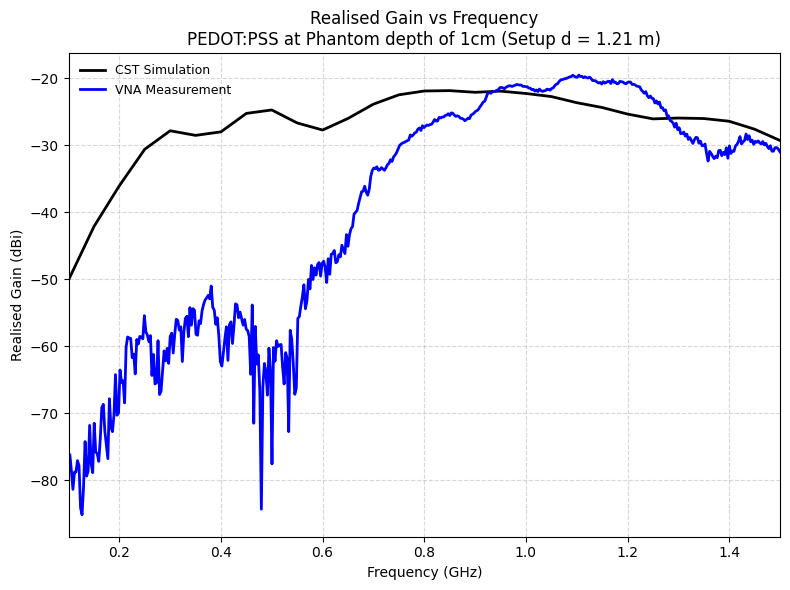

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_block sqashed 1_1.21m.png


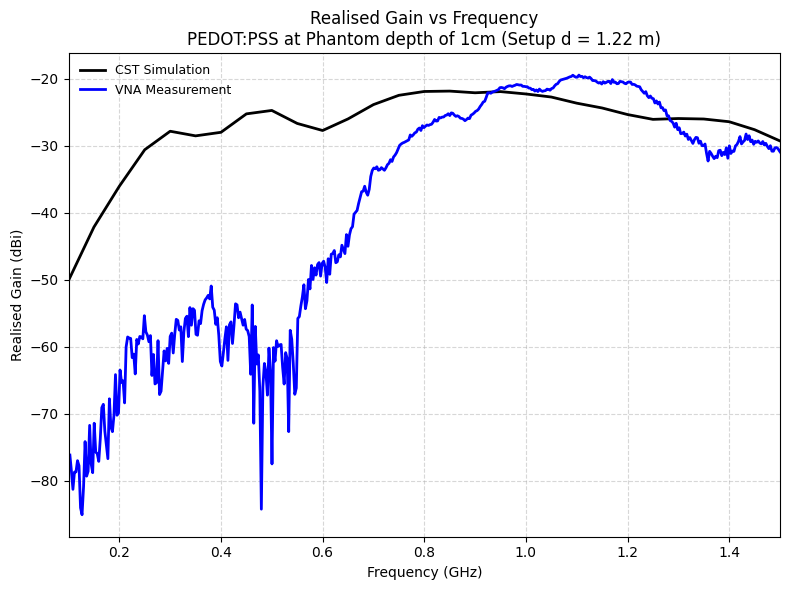

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_block sqashed 1_1.22m.png


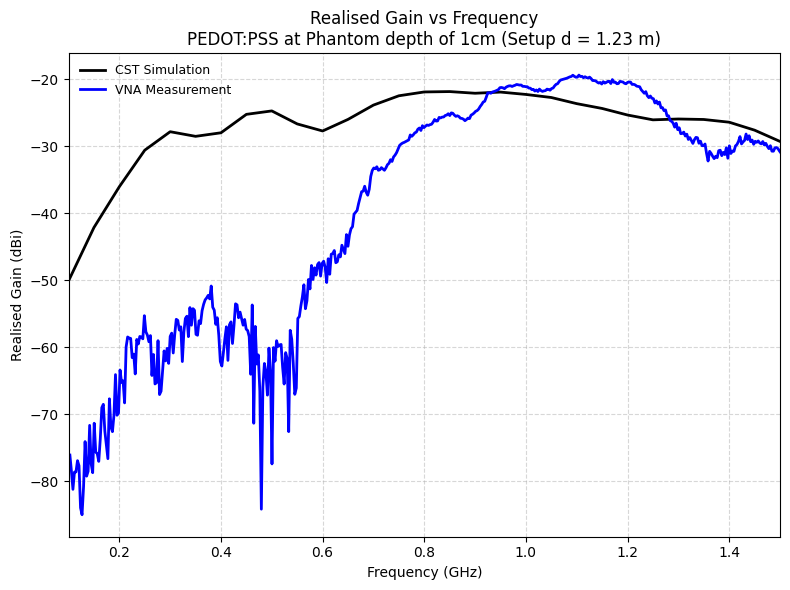

Saved: Gain_plot_pedot_Dipole_F_10M_3000MHz_block sqashed 1_1.23m.png


In [ ]:
#----------------------------------------------
# BLOCK SQASHED 1
# ----------------------------------------------

!pip install -q scikit-rf

import os
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LOAD S2P FILE
# ------------------------------------------------
s2p_file = "pedot_Dipole_F_10M_3000MHz_block sqashed 1.s2p"
ntwk = rf.Network(s2p_file)

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep from 1.20 m to 1.50 m
distances = np.arange(1.21, 1.23, 0.01)

# ------------------------------------------------
# EXTRACT DATA
# ------------------------------------------------
freq = ntwk.f
s21_db = ntwk.s_db[:, 1, 0]

# ------------------------------------------------
# FILTER FREQUENCY RANGE
# ------------------------------------------------
mask = (freq >= 0.1e9) & (freq <= 3e9)
freq = freq[mask]
s21_db = s21_db[mask]

# ------------------------------------------------
# RECEIVED POWER
# ------------------------------------------------
Pr = s21_db

# Get filename without extension
title_name = os.path.splitext(os.path.basename(s2p_file))[0]

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:
    # Free Space Path Loss
    fspl = (
        20 * np.log10(d)
        + 20 * np.log10(freq)
        + 20 * np.log10(4 * np.pi / c)
    )

    # Calculate Gain
    Gt = Pr - Pt + fspl - Gr

    # ------------------------------------------------
    # CREATE FIGURE
    # ------------------------------------------------
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # VNA Measurement
    plt.plot(
        freq / 1e9,
        Gt,
        color="blue",
        linewidth=2,
        label=f"VNA Measurement"
    )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 1.5)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Realised Gain (dBi)")
    plt.title(f"Realised Gain vs Frequency\nPEDOT:PSS at Phantom depth of 1cm (Setup d = {d:.2f} m)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=9, loc="best", frameon=False)
    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
    filename = f"Gain_plot_{title_name}_{d:.2f}m.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {filename}")

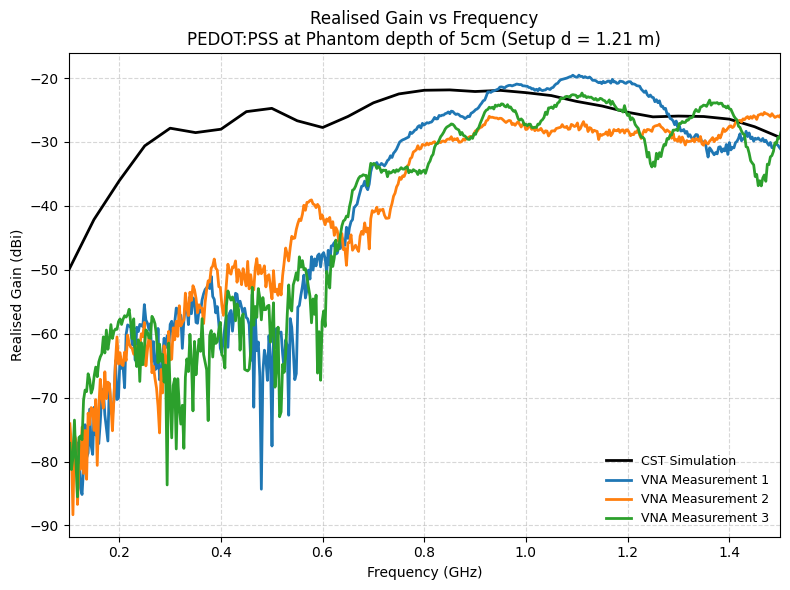

Saved: Gain_plot_multi_1.21m.png


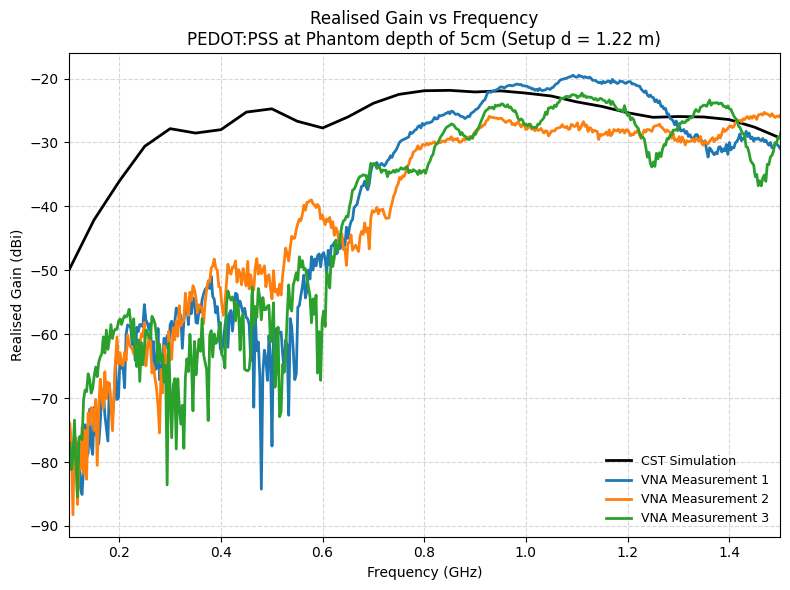

Saved: Gain_plot_multi_1.22m.png


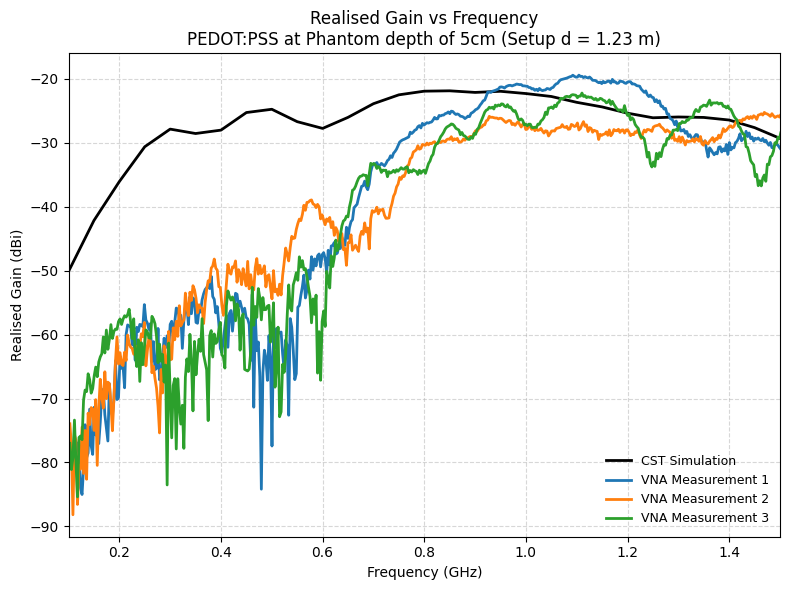

Saved: Gain_plot_multi_1.23m.png


In [ ]:
# ----------------------------------------------
# BLOCK SQUASHED 1 - MULTI-FILE OVERLAY VERSION
# ----------------------------------------------

!pip install -q scikit-rf

import os
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("pedotUpdatedphantom_rlzGain_frequency_phantom.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LIST OF S2P FILES TO PLOT
# ------------------------------------------------
s2p_files = [
    "pedot_Dipole_F_10M_3000MHz_block sqashed 1.s2p",
    "pedot_Dipole_F_10M_3000MHz_block sqashed 2.s2p",
    "pedot_Dipole_F_10M_3000MHz_thick block sqashed 1.s2p",
    # add more files here
]

# Optional custom labels for legend
labels = [
    "VNA Measurement 1",
    "VNA Measurement 2",
    "VNA Measurement 3",
]

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep
distances = np.arange(1.21, 1.23, 0.01)

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:

    # Create one figure for this distance
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # ------------------------------------------------
    # LOOP THROUGH ALL S2P FILES
    # ------------------------------------------------
    for i, s2p_file in enumerate(s2p_files):
        ntwk = rf.Network(s2p_file)

        freq = ntwk.f
        s21_db = ntwk.s_db[:, 1, 0]

        # Filter frequency range
        mask = (freq >= 0.1e9) & (freq <= 3e9)
        freq_filt = freq[mask]
        s21_db_filt = s21_db[mask]

        # Received power
        Pr = s21_db_filt

        # Free Space Path Loss
        fspl = (
            20 * np.log10(d)
            + 20 * np.log10(freq_filt)
            + 20 * np.log10(4 * np.pi / c)
        )

        # Calculate Gain
        Gt = Pr - Pt + fspl - Gr

        # Label
        if i < len(labels):
            line_label = labels[i]
        else:
            line_label = os.path.splitext(os.path.basename(s2p_file))[0]

        # Plot this file on same graph
        plt.plot(
            freq_filt / 1e9,
            Gt,
            linewidth=2,
            label=line_label
        )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 1.5)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Realised Gain (dBi)")
    plt.title(f"Realised Gain vs Frequency\nPEDOT:PSS at Phantom depth of 5cm (Setup d = {d:.2f} m)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=9, loc="best", frameon=False)
    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
    filename = f"Gain_plot_multi_{d:.2f}m.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {filename}")

In [ ]:

!pip install scikit-rf

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
txt_file = "CST_Copper_PhantomRemoved_S11.txt"
s2p_file = "CopperFreespaceLOS_7thMay10MHzto6Ghz.s2p"

# -----------------------------
# Load CST TXT file
# Assumes:
# Column 1 = Frequency
# Column 2 = S11 magnitude (dB)
# -----------------------------
txt_data = np.loadtxt(txt_file)

freq_txt = txt_data[:, 0]
s11_txt = txt_data[:, 1]

# Convert frequency to GHz if needed
# Uncomment if frequencies are in Hz
# freq_txt = freq_txt / 1e9

# -----------------------------
# Load Touchstone S2P file
# -----------------------------
freq_s2p = []
s11_s2p_db = []

with open(s2p_file, 'r') as f:
    for line in f:
        line = line.strip()

        # Skip comments and option lines
        if not line or line.startswith('!'):
            continue

        # Parse option line
        if line.startswith('#'):
            option_line = line.upper()

            # Determine frequency unit
            if 'GHZ' in option_line:
                freq_scale = 1
            elif 'MHZ' in option_line:
                freq_scale = 1e-3
            elif 'KHZ' in option_line:
                freq_scale = 1e-6
            elif 'HZ' in option_line:
                freq_scale = 1e-9
            else:
                freq_scale = 1

            # Determine data format
            if 'DB' in option_line:
                data_format = 'DB'
            elif 'MA' in option_line:
                data_format = 'MA'
            elif 'RI' in option_line:
                data_format = 'RI'

            continue

        values = line.split()

        # Standard S2P has:
        # freq S11 S21 S12 S22
        # each S-param has 2 values depending on format
        values = [float(v) for v in values]

        freq = values[0] * freq_scale

        if data_format == 'DB':
            s11_db = values[1]

        elif data_format == 'MA':
            mag = values[1]
            s11_db = 20 * np.log10(mag)

        elif data_format == 'RI':
            real = values[1]
            imag = values[2]
            mag = np.sqrt(real**2 + imag**2)
            s11_db = 20 * np.log10(mag)

        freq_s2p.append(freq)
        s11_s2p_db.append(s11_db)

freq_s2p = np.array(freq_s2p)
s11_s2p_db = np.array(s11_s2p_db)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq_txt, s11_txt,
         label='CST Simulation',
         linewidth=2)

plt.plot(freq_s2p, s11_s2p_db,
         label='VNA Measurement',
         linewidth=2)

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('S11 Comparison for Copper Meandered Dipole Antenna in Freespace LOS (No phantom)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Sim_and_Measurements_S11_plot.png", dpi=300, bbox_inches='tight')


plt.show()


FileNotFoundError: CST_Copper_PhantomRemoved_S11.txt not found.

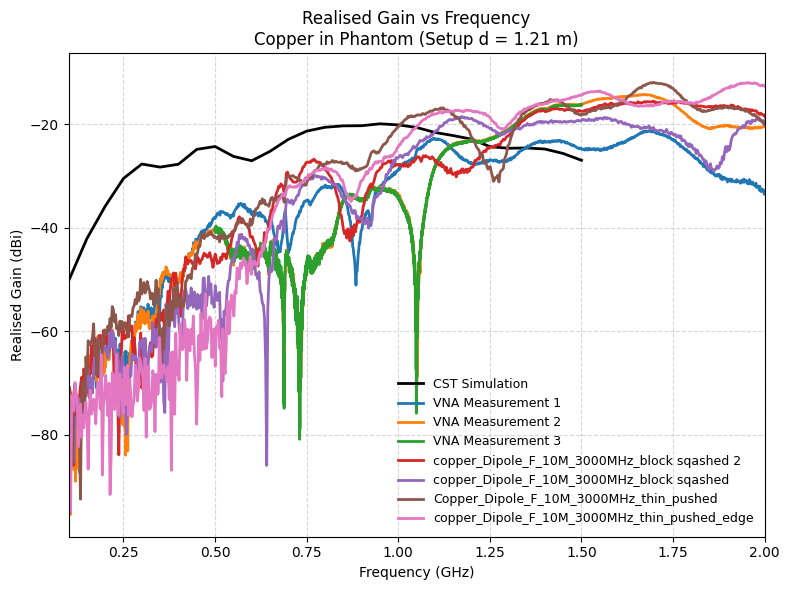

Saved: Gain_plot_multi_1.21m.png


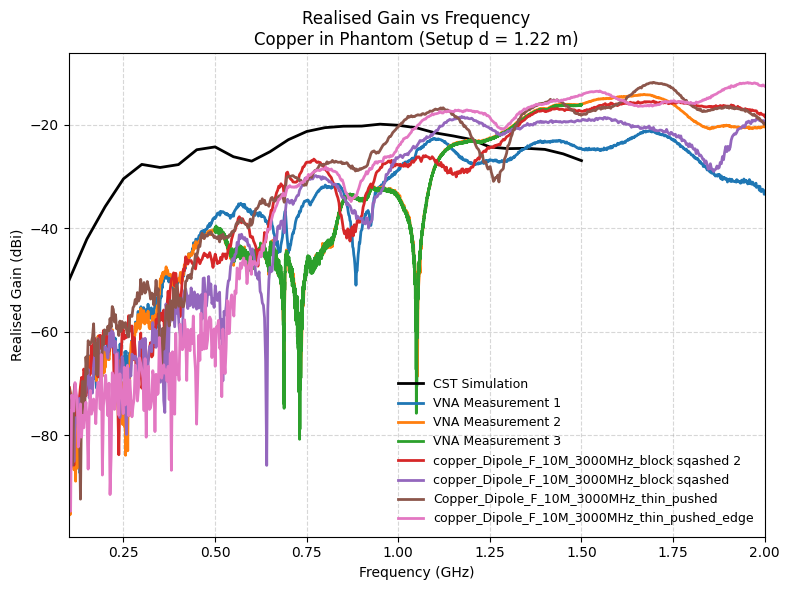

Saved: Gain_plot_multi_1.22m.png


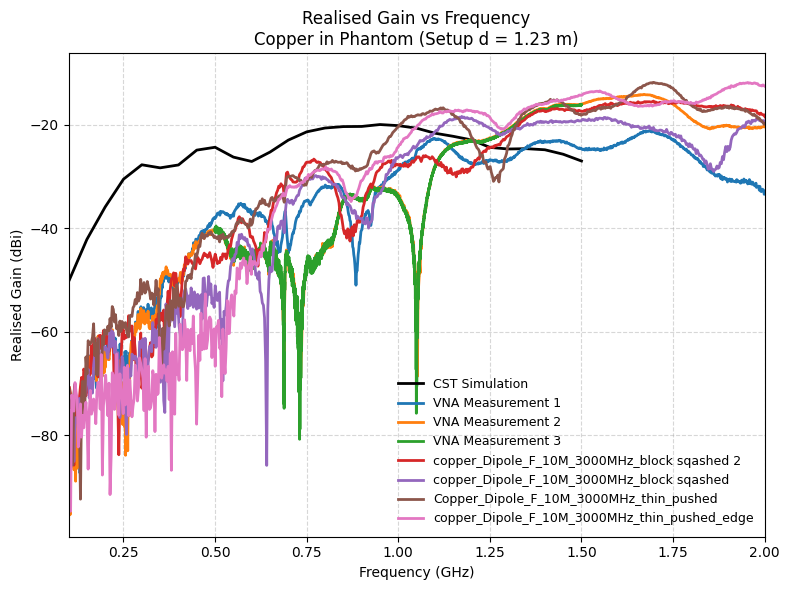

Saved: Gain_plot_multi_1.23m.png


In [ ]:
# ----------------------------------------------
# BLOCK SQUASHED 1 - MULTI-FILE OVERLAY VERSION
# ----------------------------------------------

!pip install -q scikit-rf

import os
import numpy as np
import skrf as rf
import matplotlib.pyplot as plt

# ------------------------------------------------
# LOAD CST DATA
# ------------------------------------------------
data = np.loadtxt("CopperUpdatedPhantom_rlzGain.txt")
x3 = data[:, 0]
y3 = data[:, 1]

# ------------------------------------------------
# LIST OF S2P FILES TO PLOT
# ------------------------------------------------
s2p_files = [
    "Copper_Dipole_Ave8,F_10M_6000MHz_think.s2p",
    "Copper_Dipole_Ave10,F_10M_6000MHz.s2p",
    "Copper_Dipole_Ave10,F_500M_1500MHz.s2p",
    "copper_Dipole_F_10M_3000MHz_block sqashed 2.s2p",
    "copper_Dipole_F_10M_3000MHz_block sqashed.s2p",
    "Copper_Dipole_F_10M_3000MHz_thin_pushed.s2p",
    "copper_Dipole_F_10M_3000MHz_thin_pushed_edge.s2p"
    # add more files here
]

# Optional custom labels for legend
labels = [
    "VNA Measurement 1",
    "VNA Measurement 2",
    "VNA Measurement 3",


]

# ------------------------------------------------
# USER INPUTS
# ------------------------------------------------
Gr = 6
Pt = 0
c = 3e8

# Distance sweep
distances = np.arange(1.21, 1.23, 0.01)

# ------------------------------------------------
# LOOP THROUGH DISTANCES
# ------------------------------------------------
for d in distances:

    # Create one figure for this distance
    plt.figure(figsize=(8, 6))

    # CST Simulation
    plt.plot(
        x3,
        y3,
        color="black",
        linewidth=2,
        label="CST Simulation"
    )

    # ------------------------------------------------
    # LOOP THROUGH ALL S2P FILES
    # ------------------------------------------------
    for i, s2p_file in enumerate(s2p_files):
        ntwk = rf.Network(s2p_file)

        freq = ntwk.f
        s21_db = ntwk.s_db[:, 1, 0]

        # Filter frequency range
        mask = (freq >= 0.1e9) & (freq <= 6e9)
        freq_filt = freq[mask]
        s21_db_filt = s21_db[mask]

        # Received power
        Pr = s21_db_filt

        # Free Space Path Loss
        fspl = (
            20 * np.log10(d)
            + 20 * np.log10(freq_filt)
            + 20 * np.log10(4 * np.pi / c)
        )

        # Calculate Gain
        Gt = Pr - Pt + fspl - Gr

        # Label
        if i < len(labels):
            line_label = labels[i]
        else:
            line_label = os.path.splitext(os.path.basename(s2p_file))[0]

        # Plot this file on same graph
        plt.plot(
            freq_filt / 1e9,
            Gt,
            linewidth=2,
            label=line_label
        )

    # ------------------------------------------------
    # FORMATTING
    # ------------------------------------------------
    plt.xlim(0.1, 2)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Realised Gain (dBi)")
    plt.title(f"Realised Gain vs Frequency\nCopper in Phantom (Setup d = {d:.2f} m)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=9, loc="best", frameon=False)
    plt.tight_layout()

    # ------------------------------------------------
    # SAVE FIGURE
    # ------------------------------------------------
    filename = f"Gain_plot_multi_{d:.2f}m.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {filename}")

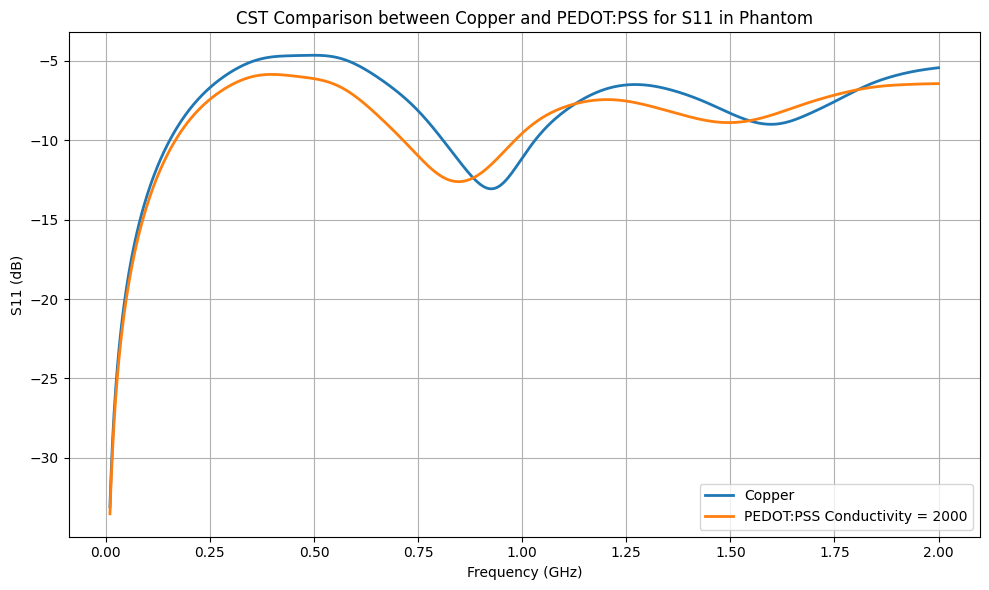

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
txt_file_1 = "CST_Copper_S11_WithPhantom.txt"
txt_file_2 = "CST_PEDOT_S11_2000.txt"

# -----------------------------
# Load first CST TXT file
# Assumes:
# Column 1 = Frequency
# Column 2 = S11 magnitude (dB)
# -----------------------------
txt_data_1 = np.loadtxt(txt_file_1)

freq_txt_1 = txt_data_1[:, 0]
s11_txt_1 = txt_data_1[:, 1]

# -----------------------------
# Load second CST TXT file
# -----------------------------
txt_data_2 = np.loadtxt(txt_file_2)

freq_txt_2 = txt_data_2[:, 0]
s11_txt_2 = txt_data_2[:, 1]

# Convert frequency to GHz if needed
# Uncomment if frequencies are in Hz
# freq_txt_1 = freq_txt_1 / 1e9
# freq_txt_2 = freq_txt_2 / 1e9

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq_txt_1, s11_txt_1,
         label='Copper',
         linewidth=2)

plt.plot(freq_txt_2, s11_txt_2,
         label='PEDOT:PSS Conductivity = 2000',
         linewidth=2)

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('CST Comparison between Copper and PEDOT:PSS for S11 in Phantom')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Sim_S11_Comparison_plot.png", dpi=300, bbox_inches='tight')

plt.show()

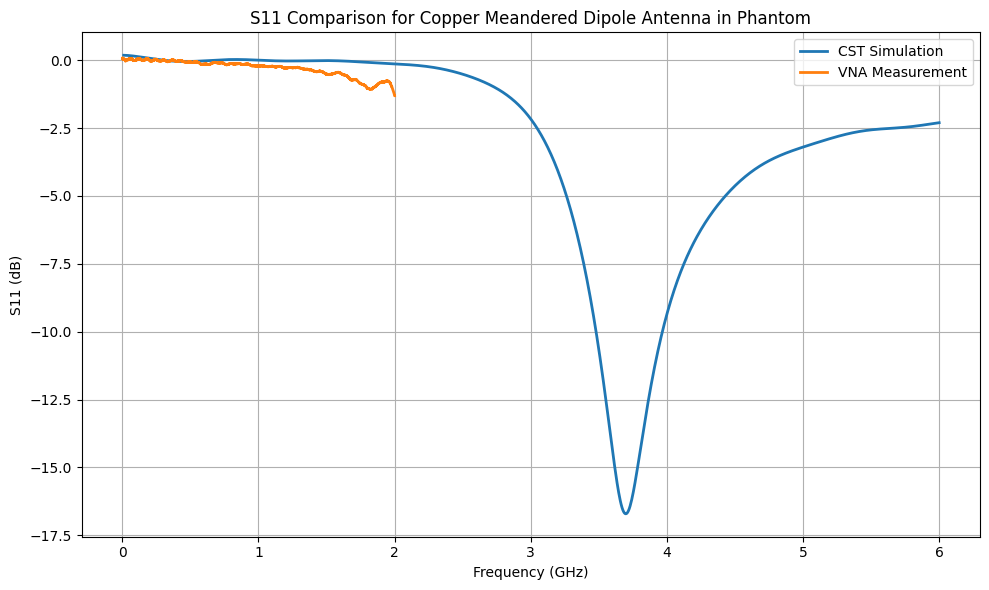

In [ ]:

!pip install scikit-rf

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
txt_file = "CST_Copper_S11_WithPhantom.txt"
s2p_file = "Alexander_implant_Copper_pHANTOM_to_Horn-50CM.s2p"

# -----------------------------
# Load CST TXT file
# Assumes:
# Column 1 = Frequency
# Column 2 = S11 magnitude (dB)
# -----------------------------
txt_data = np.loadtxt(txt_file)

freq_txt = txt_data[:, 0]
s11_txt = txt_data[:, 1]

# Convert frequency to GHz if needed
# Uncomment if frequencies are in Hz
# freq_txt = freq_txt / 1e9

# -----------------------------
# Load Touchstone S2P file
# -----------------------------
freq_s2p = []
s11_s2p_db = []

with open(s2p_file, 'r') as f:
    for line in f:
        line = line.strip()

        # Skip comments and option lines
        if not line or line.startswith('!'):
            continue

        # Parse option line
        if line.startswith('#'):
            option_line = line.upper()

            # Determine frequency unit
            if 'GHZ' in option_line:
                freq_scale = 1
            elif 'MHZ' in option_line:
                freq_scale = 1e-3
            elif 'KHZ' in option_line:
                freq_scale = 1e-6
            elif 'HZ' in option_line:
                freq_scale = 1e-9
            else:
                freq_scale = 1

            # Determine data format
            if 'DB' in option_line:
                data_format = 'DB'
            elif 'MA' in option_line:
                data_format = 'MA'
            elif 'RI' in option_line:
                data_format = 'RI'

            continue

        values = line.split()

        # Standard S2P has:
        # freq S11 S21 S12 S22
        # each S-param has 2 values depending on format
        values = [float(v) for v in values]

        freq = values[0] * freq_scale

        if data_format == 'DB':
            s11_db = values[1]

        elif data_format == 'MA':
            mag = values[1]
            s11_db = 20 * np.log10(mag)

        elif data_format == 'RI':
            real = values[1]
            imag = values[2]
            mag = np.sqrt(real**2 + imag**2)
            s11_db = 20 * np.log10(mag)

        freq_s2p.append(freq)
        s11_s2p_db.append(s11_db)

freq_s2p = np.array(freq_s2p)
s11_s2p_db = np.array(s11_s2p_db)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq_txt, s11_txt,
         label='CST Simulation',
         linewidth=2)

plt.plot(freq_s2p, s11_s2p_db,
         label='VNA Measurement',
         linewidth=2)

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('S11 Comparison for Copper Meandered Dipole Antenna in Phantom')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("S11_Copper_Phantom_plot.png", dpi=300, bbox_inches='tight')


plt.show()
